# Projekt MAPB – Milestone 1: Zrozumienie zbioru danych (Cotton Candy)

Ten notebook realizuje pierwszy kamień milowy projektu z przedmiotu **Modelowanie i analiza procesów biznesowych** dla zbioru danych *Cotton Candy* 

## Kontekst systemu i zbioru danych

**System:** Zautomatyzowana maszyna do produkcji waty cukrowej sterowana przez robota **Cottonbot**, zarządzanego przez silnik wykonywania procesów **CPEE** (Controlled Process Execution Engine, cpee.org). Każde wywołanie procesu jest logowane jako plik XES w formacie YAML.

**Typ zdarzeń:** Komendy robotyczne i zdarzenia systemowe, m.in.:
- `move_touch` / `move_touch_down` – dotknięcie rożka przez ramię robota,
- `move_max` – ruch do pozycji maksymalnej (nawijanie waty),
- `move_place` – odkładanie gotowej waty,
- zdarzenia kontrolne (`state/change`, `endpoints/change`) emitowane przez silnik CPEE.

**Hierarchia procesu:** Dane mają zagnieżdżoną strukturę procesów i podprocesów:
```
Create N Cotton Candies  (proces główny)
  └─ Cottonbot - Run with Data Collection  (podproces na jedną watę)
       ├─ move_touch
       │    └─ move_touch_down (×3)
       ├─ move_max
       └─ move_place
```
Każdy plik `*.xes.yaml` odpowiada **jednemu wywołaniu (pod)procesu**. Plik `index.txt` w każdym batchu opisuje tę hierarchię.

**Struktura danych:** Batche (`batch-0` … `batch-20`) zawierają łącznie ~2690 plików XES/YAML zebranych z różnych sesji produkcyjnych.

## Konfiguracja środowiska (venv + uv)

Aby uruchomić ten notebook lokalnie w oddzielnym środowisku Pythona:

1. W terminalu przejdź do katalogu projektu `MAPB`.
2. Utwórz środowisko wirtualne przy pomocy uv:
   - `uv venv .venv`
3. Aktywuj środowisko (PowerShell / VS Code terminal):
   - `.venv\Scripts\activate`
4. Zainstaluj wymagane pakiety:
   - `uv pip install -r requirements.txt`
5. W VS Code / Jupyter wybierz kernel Pythona ze środowiska `.venv` i uruchom wszystkie komórki notebooka.

In [1]:
# 1. Import bibliotek i konfiguracja środowiska

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

# Ustawienia wyświetlania
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

# Automatyczne wykrywanie katalogu projektu
candidate_base_dirs = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
BASE_DIR = next((p.resolve() for p in candidate_base_dirs if (p / "cotton-candy").exists()), Path.cwd().resolve())
DATA_DIR = BASE_DIR / "cotton-candy"

if not DATA_DIR.exists():
    raise FileNotFoundError(
        f"Nie znaleziono katalogu z danymi: {DATA_DIR}. Ustaw BASE_DIR ręcznie na katalog projektu MAPB."
    )

xes_files = sorted(DATA_DIR.glob("batch-*/*.xes.yaml"))
process_files = sorted(DATA_DIR.glob("batch-*/*-process.yaml"))

print("Katalog bazowy:", BASE_DIR)
print("Katalog danych:", DATA_DIR)
print("Liczba plików *.xes.yaml:", len(xes_files))
print("Liczba plików *-process.yaml:", len(process_files))
print("Przykładowe batche:", sorted(p.name for p in DATA_DIR.iterdir() if p.is_dir())[:5], "...")

Katalog bazowy: C:\Users\dusza\Documents\Studia\7semestr\MAPB
Katalog danych: C:\Users\dusza\Documents\Studia\7semestr\MAPB\cotton-candy
Liczba plików *.xes.yaml: 1294
Liczba plików *-process.yaml: 33
Przykładowe batche: ['batch-0', 'batch-1', 'batch-10', 'batch-11', 'batch-12'] ...


## 2. Wczytanie przykładowego logu zdarzeń z Cotton Candy



In [2]:

from typing import List, Dict, Any


def load_xes_yaml(path: Path) -> pd.DataFrame:
    """Wczytuje plik XES zapisany jako YAML i zwraca DataFrame z eventami.

    Każdy blok `event:` po separatorze `---` staje się jednym wierszem w tabeli.
    Zagnieżdżone struktury trzymamy jako słowniki / listy (do dalszej analizy).
    """
    with path.open("r", encoding="utf-8") as f:
        docs = list(yaml.safe_load_all(f))

    # Pierwszy dokument to zwykle metadata logu (pole `log`)
    meta = docs[0].get("log", {}) if docs and isinstance(docs[0], dict) else {}

    events: List[Dict[str, Any]] = []
    for doc in docs[1:]:
        if not isinstance(doc, dict):
            continue
        ev = doc.get("event", {})
        if not ev:
            continue
        flat: Dict[str, Any] = {}
        for k, v in ev.items():
            # zamieniamy nietypowe klucze typu "concept:name" na przyjaźniejsze nazwy
            key = k.replace(":", "_")
            flat[key] = v
        # dodajemy informacje z meta (id instancji itp.)
        for k, v in meta.items():
            if isinstance(v, dict):
                for kk, vv in v.items():
                    flat[f"meta_{k}_{kk}"] = vv
            else:
                flat[f"meta_{k}"] = v
        events.append(flat)

    df = pd.json_normalize(events, sep="_")
    return df


# wybierzmy przykładowy plik z batch-0
example_file = next((p for p in (DATA_DIR / "batch-0").glob("*.xes.yaml")), None)
print("Przykładowy plik:", example_file)

df_events = load_xes_yaml(example_file)
df_events.head()

Przykładowy plik: C:\Users\dusza\Documents\Studia\7semestr\MAPB\cotton-candy\batch-0\028e282d-26a3-4ae8-909e-a033e6794cc8.xes.yaml


,concept_instance,id_id,cpee_activity,cpee_instance,lifecycle_transition,cpee_lifecycle_transition,cpee_state,time_timestamp,meta_namespaces_stream,meta_namespaces_ssn,meta_namespaces_sosa,meta_xes_creator,meta_xes_features,meta_extension_time,meta_extension_concept,meta_extension_id,meta_extension_lifecycle,meta_extension_cpee,meta_extension_stream,meta_trace_concept:name,meta_trace_cpee:name,meta_trace_cpee:instance,meta_global_trace_concept:name,meta_global_trace_cpee:name,meta_global_event_concept:instance,meta_global_event_concept:name,meta_global_event_concept:endpoint,meta_global_event_id:id,meta_global_event_cpee:uuid,meta_global_event_lifecycle:transition,meta_global_event_cpee:lifecycle:transition,meta_global_event_time:timestamp,data,cpee_description,cpee_change_uuid,concept_name,cpee_activity_uuid,concept_endpoint,data_CPEE-INSTANCE,data_CPEE-INSTANCE-URL,data_CPEE-INSTANCE-UUID,data_CPEE-BEHAVIOR
0,61168,external,external,028e282d-26a3-4ae8-909e-a033e6794cc8,unknown,state/change,ready,2025-07-28T01:44:28.602373+02:00,https://cpee.org/datastream/,http://www.w3.org/ns/ssn/,http://www.w3.org/ns/sosa/,cpee.org,nested-attributes,http://www.xes-standard.org/time.xesext,http://www.xes-standard.org/concept.xesext,http://www.xes-standard.org/identity.xesext,http://www.xes-standard.org/lifecycle.xesext,http://cpee.org/cpee.xesext,https://cpee.org/datastream/datastream.xesext,61168,Create 11 Cotton Candies,028e282d-26a3-4ae8-909e-a033e6794cc8,__NOTSPECIFIED__,__NOTSPECIFIED__,-1,__NOTSPECIFIED__,__NOTSPECIFIED__,__NOTSPECIFIED__,__NOTSPECIFIED__,complete,activity/calling,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,61168,external,external,028e282d-26a3-4ae8-909e-a033e6794cc8,unknown,endpoints/change,NaN,2025-07-28T01:44:28.608118+02:00,https://cpee.org/datastream/,http://www.w3.org/ns/ssn/,http://www.w3.org/ns/sosa/,cpee.org,nested-attributes,http://www.xes-standard.org/time.xesext,http://www.xes-standard.org/concept.xesext,http://www.xes-standard.org/identity.xesext,http://www.xes-standard.org/lifecycle.xesext,http://cpee.org/cpee.xesext,https://cpee.org/datastream/datastream.xesext,61168,Create 11 Cotton Candies,028e282d-26a3-4ae8-909e-a033e6794cc8,__NOTSPECIFIED__,__NOTSPECIFIED__,-1,__NOTSPECIFIED__,__NOTSPECIFIED__,__NOTSPECIFIED__,__NOTSPECIFIED__,complete,activity/calling,,"[{'name': 'timeout', 'value': 'https://cpee.or...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,61168,external,external,028e282d-26a3-4ae8-909e-a033e6794cc8,unknown,dataelements/change,NaN,2025-07-28T01:44:28.605931+02:00,https://cpee.org/datastream/,http://www.w3.org/ns/ssn/,http://www.w3.org/ns/sosa/,cpee.org,nested-attributes,http://www.xes-standard.org/time.xesext,http://www.xes-standard.org/concept.xesext,http://www.xes-standard.org/identity.xesext,http://www.xes-standard.org/lifecycle.xesext,http://cpee.org/cpee.xesext,https://cpee.org/datastream/datastream.xesext,61168,Create 11 Cotton Candies,028e282d-26a3-4ae8-909e-a033e6794cc8,__NOTSPECIFIED__,__NOTSPECIFIED__,-1,__NOTSPECIFIED__,__NOTSPECIFIED__,__NOTSPECIFIED__,__NOTSPECIFIED__,complete,activity/calling,,"[{'name': 'batch_number', 'value': 0}, {'name'...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,61168,external,external,028e282d-26a3-4ae8-909e-a033e6794cc8,unknown,attributes/change,NaN,2025-07-28T01:44:28.610887+02:00,https://cpee.org/datastream/,http://www.w3.org/ns/ssn/,http://www.w3.org/ns/sosa/,cpee.org,nested-attributes,http://www.xes-standard.org/time.xesext,http://www.xes-standard.org/concept.xesext,http://www.xes-standard.org/identity.xesext,http://www.xes-standard.org/lifecycle.xesext,http://cpee.org/cpee.xesext,https://cpee.org/datastream/datastream.xesext,61168,Create 11 Cotton Candies,028e282d-26a3-4ae8-909e-a033e6794cc8,__NOTSPECIFIED__,__NOTSPECIFIED__,-1,__NOTSPECIFIED__,__NOTSPECIFIED__,__NOTSPECIFIED__,__NOTSPECIFIED__,complete,activity/calling,,"[{'name': 'guarded', 'value': 'none'}, {'name'...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,61168,external,external,028e282d-26a3-4ae8-909e-a

## 3. Identyfikacja kluczowych atrybutów logu zdarzeń

W tej sekcji mapujemy kolumny DataFrame na typowe atrybuty logu zdarzeń:
- **case id** – identyfikator przypadku / instancji procesu,
- **activity** – nazwa aktywności,
- **timestamp** – znacznik czasu zdarzenia,
- **resource** – zasób / wykonawca (jeśli występuje).

### Uwaga o identyfikatorach przypadku
W logach CPEE występują **dwa różne pola identyfikujące**:
- `concept:instance` – sekwencyjny numer zdarzenia w całym systemie (integer, np. `61168`). **Nie jest** identyfikatorem przypadku biznesowego.
- `cpee:instance` – UUID instancji procesu (np. `028e282d-26a3-4ae8-909e-a033e6794cc8`). To jest **prawdziwy case ID** – identyfikuje konkretne uruchomienie procesu.

W analizie jako `case_id` należy używać `cpee:instance` (UUID).

### Uwaga o zasobach (resource)
Standardowy atrybut XES `resource` **nie występuje** w tym zbiorze danych.
Jako proxy dla zasobu używamy atrybutu `concept:endpoint`, który zawiera adres URL usługi/urządzenia wykonującego daną aktywność (np. adres API robota lub sterownika).
Pole to nie jest pełnym odpowiednikiem zasobu (nie identyfikuje pracownika), ale pozwala rozróżnić, który komponent systemu obsługiwał dane zdarzenie.

In [3]:
# Prosta identyfikacja kolumn odpowiadających kluczowym atrybutom

candidate_cols = list(df_events.columns)

case_id_col = None
activity_col = None
timestamp_col = None
resource_cols = []

for c in candidate_cols:
    lc = c.lower()
    # Priorytet: cpee_instance (UUID) > concept_instance (numer sekwencji)
    if "cpee_instance" in lc and "meta_" not in lc:
        case_id_col = c  # UUID instancji – prawdziwy case ID
    elif "concept_instance" in lc and case_id_col is None:
        case_id_col = c  # fallback: numer sekwencji
    if "concept_name" in lc and "meta_" not in lc:
        activity_col = activity_col or c
    if "time_timestamp" in lc or lc.endswith("timestamp"):
        timestamp_col = timestamp_col or c
    if "resource" in lc:
        resource_cols.append(c)

print("case id:", case_id_col)
print("activity:", activity_col)
print("timestamp:", timestamp_col)
print("resources:", resource_cols)

# Konwersja kolumny timestamp na typ datetime
if timestamp_col is not None:
    df_events["timestamp"] = pd.to_datetime(df_events[timestamp_col], errors="coerce")

# Ustalamy kolumnę case_id (jeśli brak – zostawiamy None)
if case_id_col is not None:
    df_events["case_id"] = df_events[case_id_col]

if activity_col is not None:
    df_events["activity"] = df_events[activity_col]

print("\nPodgląd kluczowych kolumn:")
df_events[[c for c in ["case_id", "activity", "timestamp"] if c in df_events.columns]].head()

case id: cpee_instance
activity: concept_name
timestamp: time_timestamp
resources: []

Podgląd kluczowych kolumn:


,case_id,activity,timestamp
0,028e282d-26a3-4ae8-909e-a033e6794cc8,NaN,2025-07-28 01:44:28.602373+02:00
1,028e282d-26a3-4ae8-909e-a033e6794cc8,NaN,2025-07-28 01:44:28.608118+02:00
2,028e282d-26a3-4ae8-909e-a033e6794cc8,NaN,2025-07-28 01:44:28.605931+02:00
3,028e282d-26a3-4ae8-909e-a033e6794cc8,NaN,2025-07-28 01:44:28.610887+02:00
4,028e282d-26a3-4ae8-909e-a033e6794cc8,NaN,2025-07-28 01:44:28.616227+02:00


## 4. Analiza jakości danych

Sprawdzamy brakujące wartości, duplikaty oraz potencjalne problemy ze znacznikami czasu (np. zdarzenia wstecz w czasie w ramach jednego przypadku).

=== 4.1 Brakujące wartości ===
                         missing_count  missing_pct
cpee_description                    75        98.68
cpee_change_uuid                    75        98.68
data_CPEE-INSTANCE                  71        93.42
data_CPEE-INSTANCE-URL              71        93.42
data_CPEE-INSTANCE-UUID             71        93.42
data_CPEE-BEHAVIOR                  71        93.42
cpee_state                          69        90.79
concept_endpoint                    40        52.63
data                                33        43.42
cpee_activity_uuid                  20        26.32
concept_name                        20        26.32
activity                            20        26.32


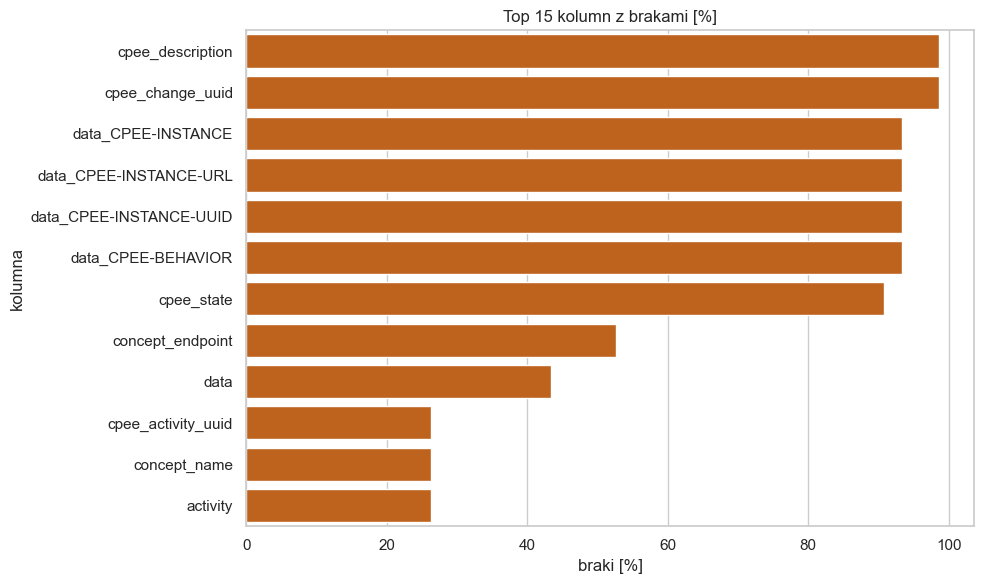


=== 4.2 Duplikaty (eventy + sensory, jeśli są dostępne) ===
Duplikaty (kolumny hashowalne): 0 | kolumny użyte: 44
Duplikaty (klucz eventowy): 0 | kolumny: ['cpee_instance', 'concept_instance', 'concept_name', 'id_id', 'time_timestamp', 'concept_endpoint']
Brak zduplikowanych rekordów w logu eventów według klucza eventowego.

--- Duplikaty w danych sensorowych (df_sensors) ---
Duplikaty sensorowe: 98 (klucz: case_id, sensor_id, timestamp, wartość, plik)
Przykładowe zduplikowane rekordy sensorowe:
                             case_id sensor_id                 sensor_timestamp                             sensor_value_raw        file_name  row_index
1309739f-950b-4d9e-8ff5-e45f86b0e549       NaN 2025-07-28 02:18:11.292897+00:00 Probe  Line 4: undefined method '[]' for nil 1-1-process.yaml       9234
1309739f-950b-4d9e-8ff5-e45f86b0e549       NaN 2025-07-28 02:18:11.327785+00:00 Probe  Line 4: undefined method '[]' for nil 1-1-process.yaml       9235
1309739f-950b-4d9e-8ff5-e45f86b0e549   

In [9]:
# 4. Analiza jakości danych: braki, duplikaty, timestampy, typy
import re

print("=== 4.1 Brakujące wartości ===")
missing_abs = df_events.isna().sum().sort_values(ascending=False)
missing_pct = (missing_abs / len(df_events) * 100).round(2)
missing_table = pd.DataFrame({
    "missing_count": missing_abs,
    "missing_pct": missing_pct,
})
print(missing_table[missing_table["missing_count"] > 0].head(25))

top_missing = missing_table[missing_table["missing_count"] > 0].head(15)
if not top_missing.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(x=top_missing["missing_pct"].values, y=top_missing.index, orient="h", color="#d95f02")
    plt.title("Top 15 kolumn z brakami [%]")
    plt.xlabel("braki [%]")
    plt.ylabel("kolumna")
    plt.tight_layout()
    plt.show()

print("\n=== 4.2 Duplikaty (eventy + sensory, jeśli są dostępne) ===")
# Duplikaty globalne na kolumnach hashowalnych
def is_scalar_na(x) -> bool:
    na = pd.isna(x)
    return bool(na) if isinstance(na, (bool, np.bool_)) else False

def is_hashable_or_scalar_na(x) -> bool:
    if is_scalar_na(x):
        return True
    try:
        hash(x)
        return True
    except TypeError:
        return False

hashable_cols = [col for col in df_events.columns if df_events[col].map(is_hashable_or_scalar_na).all()]
dup_count_hashable = df_events.duplicated(subset=hashable_cols).sum() if hashable_cols else 0
print(f"Duplikaty (kolumny hashowalne): {dup_count_hashable} | kolumny użyte: {len(hashable_cols)}")

# Duplikaty na kluczu biznesowym eventu
event_key_cols = [c for c in ["cpee_instance", "concept_instance", "concept_name", "id_id", "time_timestamp", "concept_endpoint"] if c in df_events.columns]
if event_key_cols:
    dup_count_key = df_events.duplicated(subset=event_key_cols).sum()
    print(f"Duplikaty (klucz eventowy): {dup_count_key} | kolumny: {event_key_cols}")

    dup_mask = df_events.duplicated(subset=event_key_cols, keep=False)
    if dup_mask.any():
        print("\nRekordy, które tworzą duplikaty (grupowane po kluczu eventowym):")
        dup_columns = event_key_cols + [c for c in [case_id_col, activity_col, timestamp_col] if c and c not in event_key_cols]
        dup_preview = (
            df_events.loc[dup_mask, dup_columns]
            .copy()
            .assign(row_index=lambda x: x.index)
            .sort_values(dup_columns)
        )
        print(dup_preview.head(20).to_string(index=False))
        print("Najczęstsze powtórzone wartości klucza eventowego:")
        print(df_events.loc[dup_mask, event_key_cols].value_counts().head(10))
    else:
        print("Brak zduplikowanych rekordów w logu eventów według klucza eventowego.")

# Duplikaty w danych sensorowych (jeśli df_sensors już istnieje)
if "df_sensors" in globals() and isinstance(df_sensors, pd.DataFrame) and not df_sensors.empty:
    print("\n--- Duplikaty w danych sensorowych (df_sensors) ---")
    sensor_dup_key = (
        df_sensors["case_id"].astype(str)
        + "|" + df_sensors["sensor_id"].astype(str)
        + "|" + df_sensors["sensor_timestamp"].astype(str)
        + "|" + df_sensors["sensor_value_raw"].map(lambda x: repr(x))
        + "|" + df_sensors["file_name"].astype(str)
    )
    sensor_dup_mask = sensor_dup_key.duplicated(keep=False)
    sensor_dup_count = sensor_dup_mask.sum()
    print(f"Duplikaty sensorowe: {int(sensor_dup_count)} (klucz: case_id, sensor_id, timestamp, wartość, plik)")
    if sensor_dup_mask.any():
        sensor_dup_preview = (
            df_sensors.loc[sensor_dup_mask, ["case_id", "sensor_id", "sensor_timestamp", "sensor_value_raw", "file_name"]]
            .copy()
            .assign(row_index=lambda x: x.index)
            .sort_values(["case_id", "sensor_id", "sensor_timestamp", "sensor_value_raw", "file_name"])
        )
        print("Przykładowe zduplikowane rekordy sensorowe:")
        print(sensor_dup_preview.head(20).to_string(index=False))
        print("Najczęstsze powtórzone wartości klucza sensorowego:")
        print(sensor_dup_key[sensor_dup_mask].value_counts().head(10))
else:
    print("\n--- Duplikaty w danych sensorowych (df_sensors) ---")
    print("Brak df_sensors w tym momencie - uruchom sekcję 8 przed analizą duplikatów sensorów.")

print("\n=== 4.3 Niespójności timestampów ===")
if timestamp_col is not None:
    ts_raw = df_events[timestamp_col]
    ts_parsed = pd.to_datetime(ts_raw, errors="coerce", utc=True)
    parse_failed = ((ts_raw.notna()) & (ts_parsed.isna())).sum()

    iso_tz_re = re.compile(r"^\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}(?:\.\d+)?(?:Z|[+-]\d{2}:\d{2})$")
    plain_dt_re = re.compile(r"^\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}(?:\.\d+)?$")

    def ts_classify(x):
        if pd.isna(x):
            return "missing"
        if isinstance(x, str) and iso_tz_re.match(x):
            return "iso8601_with_tz"
        if isinstance(x, str) and plain_dt_re.match(x):
            return "plain_datetime"
        if isinstance(x, str):
            return "other_string"
        return type(x).__name__

    ts_class = ts_raw.map(ts_classify)
    print("Nieudane parsowanie timestamp:", int(parse_failed))
    print("Formaty timestamp:")
    print(ts_class.value_counts())

if "case_id" in df_events.columns and "timestamp" in df_events.columns:
    tmp = df_events.dropna(subset=["case_id", "timestamp"]).copy()
    tmp = tmp.sort_values(["case_id", "timestamp"])
    tmp["delta_sec"] = tmp.groupby("case_id")["timestamp"].diff().dt.total_seconds()
    negative_deltas = tmp[tmp["delta_sec"] < 0]
    print("Ujemne różnice czasu (globalnie):", len(negative_deltas))

    if not negative_deltas.empty:
        bad_cases = (
            negative_deltas.groupby("case_id")["delta_sec"]
            .agg(["count", "min", "max"])
            .sort_values("count", ascending=False)
        )
        print("\nTop 10 przypadków z niespójną kolejnością czasu:")
        print(bad_cases.head(10))

        plt.figure(figsize=(7, 4))
        sns.histplot(negative_deltas["delta_sec"], bins=30, color="#7570b3")
        plt.title("Rozkład ujemnych różnic czasu (sekundy)")
        plt.xlabel("delta_sec")
        plt.ylabel("liczba zdarzeń")
        plt.tight_layout()
        plt.show()

print("\n=== 4.4 Niespójne typy danych (co je powoduje) ===")
type_check_cols = [c for c in [case_id_col, activity_col, timestamp_col, "data", "stream_datastream"] if c is not None and c in df_events.columns]

def safe_type_name(x):
    na = pd.isna(x)
    if isinstance(na, (bool, np.bool_)) and bool(na):
        return "NoneType"
    return type(x).__name__

def explain_type_inconsistency(df: pd.DataFrame, col: str, max_rows: int = 5, max_examples: int = 5):
    series = df[col]
    type_series = series.map(safe_type_name)
    type_dist = type_series.value_counts(dropna=False)
    dominant_type = type_dist.index[0]
    inconsistent_mask = type_series != dominant_type
    inconsistent_count = int(inconsistent_mask.sum())

    print(f"\nKolumna: {col}")
    print("Rozkład typów:")
    print(type_dist)

    if inconsistent_count == 0:
        print("Brak niespójności typów - wszystkie niepuste wartości mają ten sam typ dominujący.")
        return

    print(f"Niespójne wartości: {inconsistent_count} | typ dominujący: {dominant_type}")

    def repr_with_missing(value):
        if pd.isna(value):
            return "<missing>"
        return repr(value)

    offending_rows = df.loc[inconsistent_mask, [col]].copy()
    offending_rows["row_index"] = offending_rows.index
    offending_rows["python_type"] = type_series[inconsistent_mask].values
    offending_rows["value_repr"] = offending_rows[col].map(repr_with_missing)

    print("Przykładowe rekordy odstające:")
    print(offending_rows[["row_index", "python_type", "value_repr"]].head(max_rows).to_string(index=False))

    print("Najczęstsze wartości powodujące niespójność:")
    print(offending_rows["value_repr"].value_counts().head(max_examples))

for col in type_check_cols:
    explain_type_inconsistency(df_events, col)

## Wniosek do sekcji 4

Analiza jakości danych pokazuje, że większość kolumn ma spójną strukturę typów, a wykryte niespójności wynikają głównie z wartości brakujących, a nie z błędnie zapisanych typów. W szczególności w kolumnach `concept_name` oraz `data` dominują odpowiednio typy `str` i `list`, natomiast obserwowane odstępstwa to przede wszystkim `NoneType`, czyli brak wartości w części rekordów. Oznacza to, że problem nie polega na losowym mieszaniu formatów danych, lecz na niepełnym wypełnieniu pól w niektórych zdarzeniach.

W praktyce należy więc traktować te kolumny jako poprawne semantycznie, ale wymagające ostrożnego przetwarzania przy dalszej analizie. Dla kolejnych etapów eksploracji i modelowania procesów warto jawnie uwzględnić braki danych, zamiast próbować je interpretować jako odrębne typy informacji.

## 5. Podstawowe statystyki zbioru danych (eventy + sensory)

Wyznaczamy kluczowe statystyki Milestone 1:
- liczba zdarzeń, przypadków i aktywności,
- liczba danych z czujników (punkty pomiarowe), liczba typów sensorów,
- podstawowe charakterystyki długości przypadków i czasu trwania.

In [6]:
# 5. Podstawowe statystyki: eventy + sensory
from collections import Counter

n_events = len(df_events)
n_cases = df_events["case_id"].nunique() if "case_id" in df_events.columns else None
n_activities = df_events["activity"].nunique() if "activity" in df_events.columns else None

# Szybkie statystyki sensorów z plików *-process.yaml
def count_sensor_points(node):
    total = 0
    ids = Counter()
    if isinstance(node, list):
        for item in node:
            c, cids = count_sensor_points(item)
            total += c
            ids.update(cids)
    elif isinstance(node, dict):
        if "stream:id" in node and "stream:value" in node:
            sid = str(node.get("stream:id", "")).strip()
            if sid:
                ids[sid] += 1
            total += 1
        for value in node.values():
            if isinstance(value, (list, dict)):
                c, cids = count_sensor_points(value)
                total += c
                ids.update(cids)
    return total, ids

sensor_records_total = 0
sensor_ids_counter = Counter()
for p in process_files:
    with p.open("r", encoding="utf-8") as f:
        docs = [d for d in yaml.safe_load_all(f) if isinstance(d, dict)]
    for doc in docs[1:]:
        event = doc.get("event")
        if not isinstance(event, dict):
            continue
        datastream = event.get("stream:datastream")
        if datastream is None:
            continue
        c, cids = count_sensor_points(datastream)
        sensor_records_total += c
        sensor_ids_counter.update(cids)

print({
    "liczba_zdarzen": n_events,
    "liczba_przypadkow": n_cases,
    "liczba_aktywnosci": n_activities,
    "liczba_punktow_sensorowych": sensor_records_total,
    "liczba_typow_sensorow": len(sensor_ids_counter),
})

if sensor_ids_counter:
    print("\nTop 10 sensorów (liczba punktów):")
    print(pd.Series(sensor_ids_counter).sort_values(ascending=False).head(10))

# Zdarzenia na przypadek
if "case_id" in df_events.columns:
    events_per_case = df_events.groupby("case_id").size().rename("events_per_case")
    print("\nStatystyki liczby zdarzeń na przypadek:")
    print(events_per_case.describe())

# Czas trwania przypadków
if "case_id" in df_events.columns and "timestamp" in df_events.columns:
    case_durations = (
        df_events.dropna(subset=["timestamp"])
        .groupby("case_id")["timestamp"]
        .agg(["min", "max"])
)
    case_durations["duration_sec"] = (
        case_durations["max"] - case_durations["min"]
).dt.total_seconds()
    print("\nStatystyki czasu trwania przypadków [s]:")
    print(case_durations["duration_sec"].describe())

{'liczba_zdarzen': 76, 'liczba_przypadkow': 1, 'liczba_aktywnosci': 4, 'liczba_punktow_sensorowych': 38207, 'liczba_typow_sensorow': 11}

Top 10 sensorów (liczba punktów):
humidity       9434
temperature    9434
head           4717
ambient        4717
current        4700
power          4700
pos1            135
pos2             82
pos3             82
pressures        78
dtype: int64

Statystyki liczby zdarzeń na przypadek:
count     1.0
mean     76.0
std       NaN
min      76.0
25%      76.0
50%      76.0
75%      76.0
max      76.0
Name: events_per_case, dtype: float64

Statystyki czasu trwania przypadków [s]:
count       1.000000
mean     2098.571603
std              NaN
min      2098.571603
25%      2098.571603
50%      2098.571603
75%      2098.571603
max      2098.571603
Name: duration_sec, dtype: float64


## 6. Podstawowe wizualizacje (timeline, distribution, frequency)

Tworzymy kilka prostych wykresów eksploracyjnych:
- rozkład liczby zdarzeń na przypadek,
- rozkład czasu trwania przypadków,
- częstość występowania aktywności,
- timeline liczby zdarzeń w czasie.

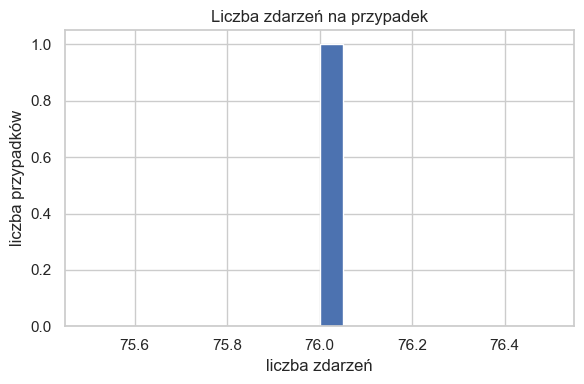

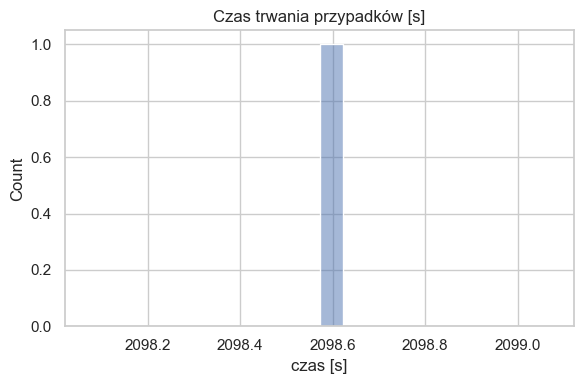

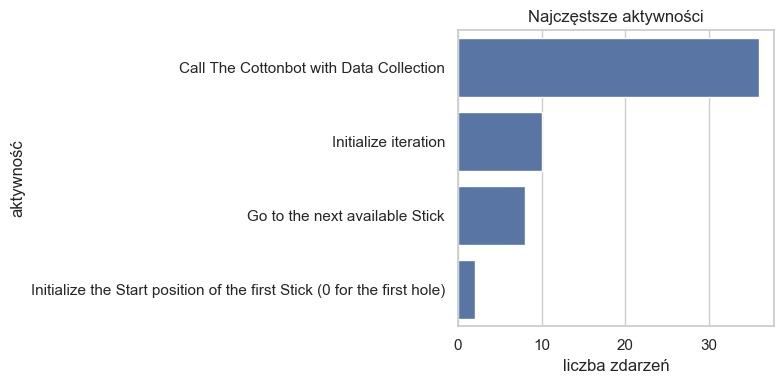

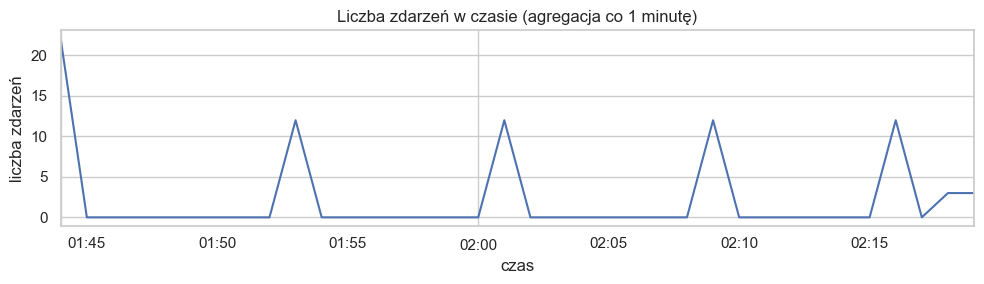

In [7]:
sns.set(style="whitegrid")

# Histogram liczby zdarzeń na przypadek
if "case_id" in df_events.columns:
    plt.figure(figsize=(6, 4))
    events_per_case.plot(kind="hist", bins=20)
    plt.title("Liczba zdarzeń na przypadek")
    plt.xlabel("liczba zdarzeń")
    plt.ylabel("liczba przypadków")
    plt.tight_layout()
    plt.show()

# Rozkład czasu trwania przypadków
if "case_id" in df_events.columns and "timestamp" in df_events.columns:
    plt.figure(figsize=(6, 4))
    sns.histplot(case_durations["duration_sec"].dropna(), bins=20, kde=True)
    plt.title("Czas trwania przypadków [s]")
    plt.xlabel("czas [s]")
    plt.tight_layout()
    plt.show()

# Częstość aktywności
if "activity" in df_events.columns:
    plt.figure(figsize=(8, 4))
    activity_counts = df_events["activity"].value_counts().head(30)
    sns.barplot(x=activity_counts.values, y=activity_counts.index, orient="h")
    plt.title("Najczęstsze aktywności")
    plt.xlabel("liczba zdarzeń")
    plt.ylabel("aktywność")
    plt.tight_layout()
    plt.show()

# Timeline – liczba zdarzeń w czasie (agregacja minutowa)
if "timestamp" in df_events.columns:
    tmp = df_events.dropna(subset=["timestamp"]).set_index("timestamp")
    events_over_time = tmp.resample("1min").size()
    plt.figure(figsize=(10, 3))
    events_over_time.plot()
    plt.title("Liczba zdarzeń w czasie (agregacja co 1 minutę)")
    plt.xlabel("czas")
    plt.ylabel("liczba zdarzeń")
    plt.tight_layout()
    plt.show()

## 7. Pełna analiza całego zapisanego procesu (wszystkie pliki `*.xes.yaml`)



Poniższa sekcja realizuje Milestone 1 na pełnym zbiorze danych (`cotton-candy/batch-*/*.xes.yaml` + `cotton-candy/batch-*/*-process.yaml`) i obejmuje:

- opis kontekstu + liczby przypadków/zdarzeń,

- identyfikację kluczowych atrybutów (`case id`, `activity`, `timestamp`, `resource`),

- analizę jakości danych (braki, duplikaty, niespójne timestampy i typy),

- EDA + statystyki podstawowe (liczba eventów, cases, activities, danych z czujników),

- wizualizacje typu timeline / distribution / frequency.

Liczba plików cases (*.xes.yaml): 1294
Liczba plików process (*-process.yaml): 33
Przetworzono plików: 200/1294
Przetworzono plików: 400/1294
Przetworzono plików: 600/1294
Przetworzono plików: 800/1294
Przetworzono plików: 1000/1294
Przetworzono plików: 1200/1294

=== PODSUMOWANIE KONTEKSTU ===
{'liczba_plikow_cases': 1294, 'liczba_cases': 1244, 'liczba_eventow': 564185, 'liczba_activities': 64, 'liczba_punktow_sensorowych': 38207, 'liczba_typow_sensorow': 11}

=== KLUCZOWE ATRYBUTY (czy są) ===
{'case_id_present': True, 'case_uuid_present': True, 'activity_present': True, 'timestamp_present': True, 'resource_proxy_present': True}

=== JAKOŚĆ DANYCH ===
Braki: {'resource': 120877, 'timestamp_raw': 80471, 'timestamp': 80471}
Duplikaty: 99743
Nieudane parsowanie timestamp: 0
Ujemne różnice czasu w case: 64840
Typy case_id: {'str': 564185}
Typy activity: {'str': 564185}
Klasy timestamp: {'iso8601_with_tz': 483714, 'missing': 80471}

=== PODSTAWOWE STATYSTYKI ===
eventy: 564185
cases: 1244

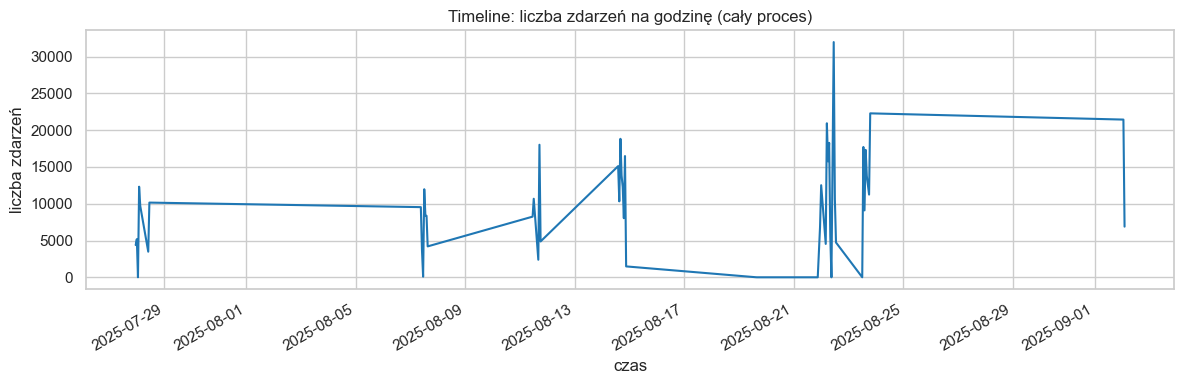

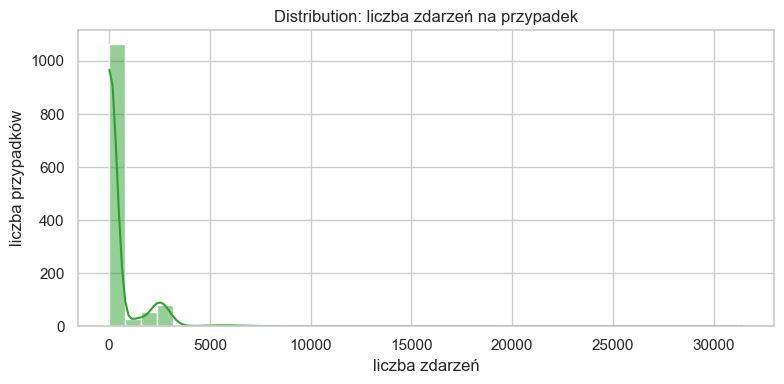

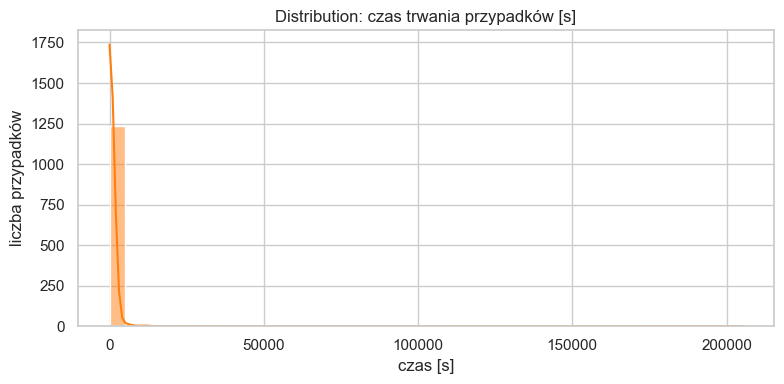

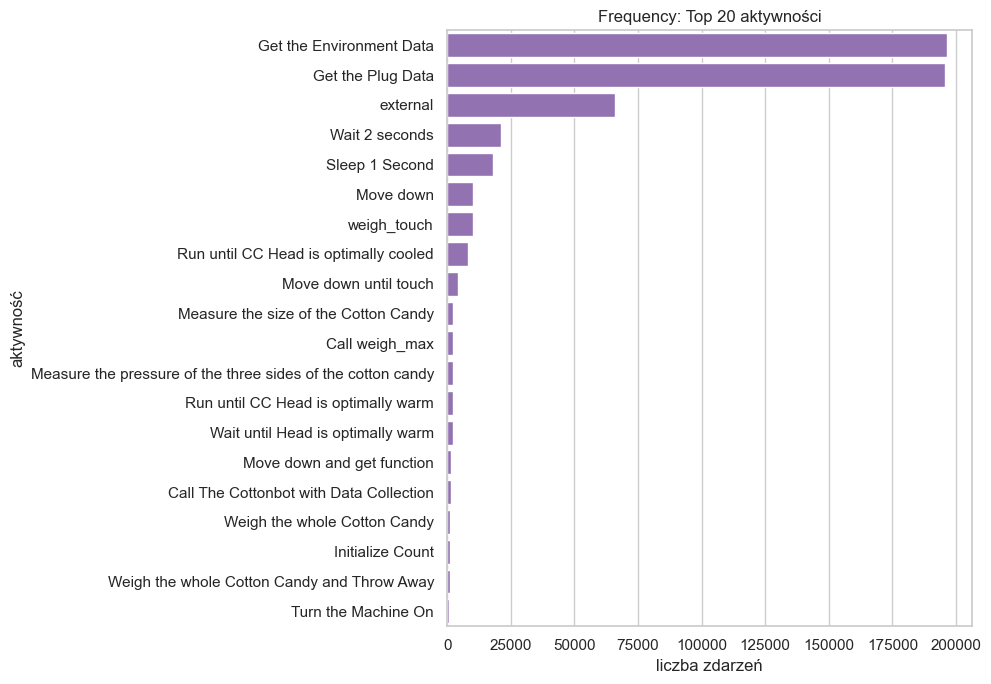

C:\Users\dusza\AppData\Local\Temp\ipykernel_2676\868814713.py:325: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_resources.values, y=top_resources.index, orient="h", palette="magma")


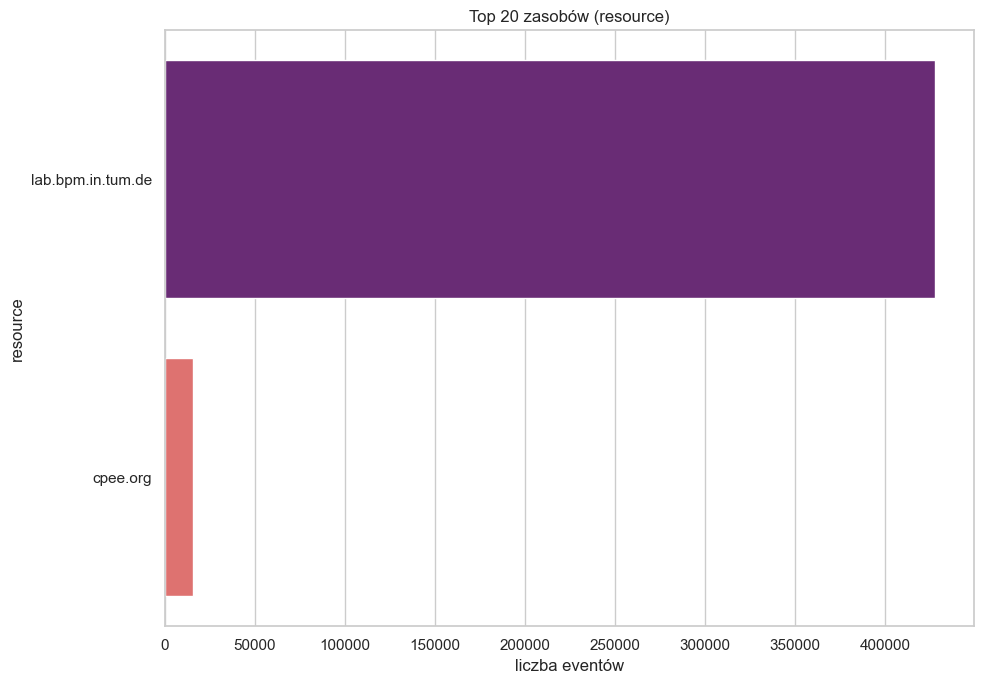

C:\Users\dusza\AppData\Local\Temp\ipykernel_2676\868814713.py:336: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=batches.index, y=batches.values, palette="Blues_d")


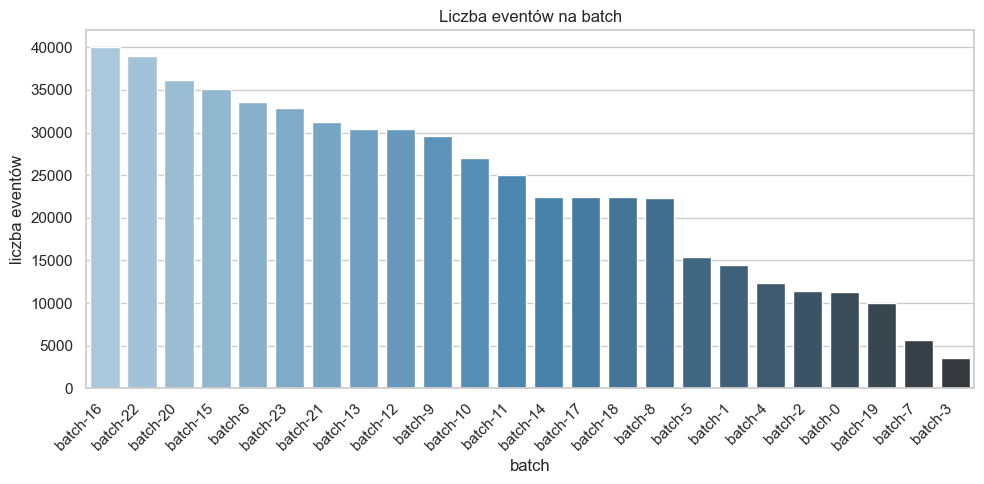

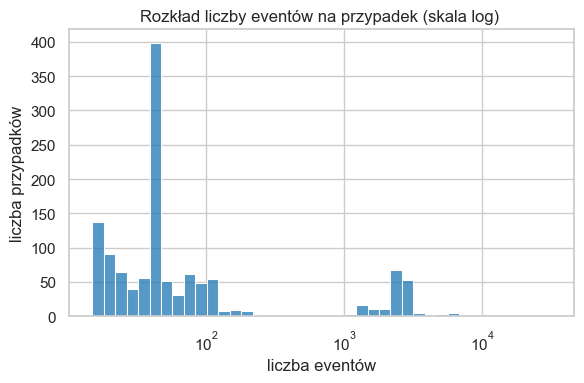

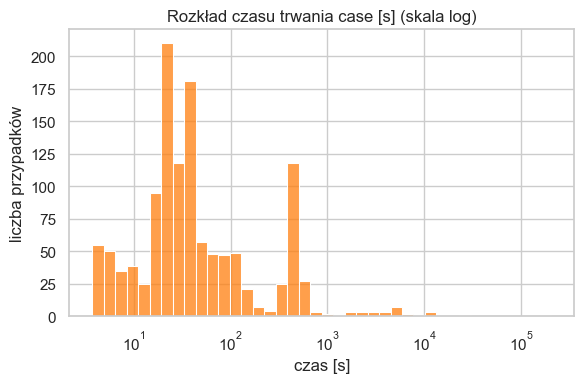

P50 czas trwania [s]: 32.3813775
P90 czas trwania [s]: 437.40596050000005
P99 czas trwania [s]: 4849.269487509997


In [ ]:
# Pełna analiza całego procesu (streaming po wszystkich plikach .xes.yaml)
from collections import Counter, defaultdict
from urllib.parse import urlparse
import re

ISO_TZ_RE = re.compile(r"^\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}(?:\.\d+)?(?:Z|[+-]\d{2}:\d{2})$")
INTEREST_KEYS = {
    "concept:instance",
    "cpee:instance",
    "concept:name",
    "time:timestamp",
    "concept:endpoint",
    "id:id",
    "cpee:activity",
    "lifecycle:transition",
    "cpee:lifecycle:transition",
}

def classify_timestamp(value):
    if value is None or value == "":
        return "missing"
    if isinstance(value, str) and ISO_TZ_RE.match(value):
        return "iso8601_with_tz"
    if isinstance(value, str):
        return "other_string"
    return type(value).__name__

def normalize_resource(endpoint):
    if not endpoint:
        return None
    endpoint = endpoint.replace("https-get://", "https://").replace("https-post://", "https://")
    parsed = urlparse(endpoint)
    return parsed.netloc if parsed.netloc else endpoint

def parse_ts(raw):
    if raw is None or raw == "":
        return None
    ts = pd.to_datetime(raw, errors="coerce", utc=True)
    return None if pd.isna(ts) else ts

def stream_events(file_path):
    current = None
    seq = 0
    with file_path.open("r", encoding="utf-8") as f:
        for raw_line in f:
            line = raw_line.rstrip("\n")

            if line == "---":
                if current is not None:
                    yield current, seq
                current = None
                continue

            if line == "event:":
                current = {}
                seq += 1
                continue

            if current is None:
                continue

            if line.startswith("  ") and not line.startswith("    "):
                stripped = line.strip()
                if ": " in stripped:
                    key, value = stripped.split(": ", 1)
                elif stripped.endswith(":"):
                    key, value = stripped[:-1], ""
                else:
                    continue

                if key in INTEREST_KEYS and key not in current:
                    current[key] = value.strip("'\"")  # usuwa otaczające apostrofy/cudzysłowy YAML

    if current is not None:
        yield current, seq

def count_sensor_points(node):
    total = 0
    ids = Counter()
    if isinstance(node, list):
        for item in node:
            c, cids = count_sensor_points(item)
            total += c
            ids.update(cids)
    elif isinstance(node, dict):
        if "stream:id" in node and "stream:value" in node:
            sid = str(node.get("stream:id", "")).strip()
            if sid:
                ids[sid] += 1
            total += 1
        for value in node.values():
            if isinstance(value, (list, dict)):
                c, cids = count_sensor_points(value)
                total += c
                ids.update(cids)
    return total, ids

def safe_type_label(value):
    if value is None:
        return "NoneType"
    if isinstance(value, str) and value == "":
        return "empty_str"
    return type(value).__name__

def track_type(field, value, details, max_samples=5):
    label = safe_type_label(value)
    details[field]["counts"][label] += 1
    samples = details[field]["samples"].setdefault(label, [])
    if len(samples) < max_samples:
        samples.append(repr(value))

all_xes_files = sorted((DATA_DIR).glob("batch-*/*.xes.yaml"))
sensor_process_files = sorted((DATA_DIR).glob("batch-*/*-process.yaml"))
print(f"Liczba plików cases (*.xes.yaml): {len(all_xes_files)}")
print(f"Liczba plików process (*-process.yaml): {len(sensor_process_files)}")

# Agregaty
total_events = 0
activity_counter = Counter()
timeline_hourly = Counter()
resource_counter = Counter()
batch_events = Counter()

missing = Counter()
type_counts = {
    "case_id": Counter(),
    "case_uuid": Counter(),
    "activity": Counter(),
    "timestamp_raw": Counter(),
    "timestamp_class": Counter(),
}

type_details = {
    "case_id": {"counts": Counter(), "samples": {}},
    "case_uuid": {"counts": Counter(), "samples": {}},
    "activity": {"counts": Counter(), "samples": {}},
    "timestamp_raw": {"counts": Counter(), "samples": {}},
}

duplicate_set = set()
duplicate_count = 0
duplicate_counter = Counter()
duplicate_examples = []
parse_failed = 0
non_monotonic = 0
neg_case_stats = {}

case_events = defaultdict(int)
case_min_ts = {}
case_max_ts = {}
case_prev_ts = {}
case_batch = {}  # mapowanie case -> batch_name
case_batch = {}  # mapowanie case -> batch do wizualizacji per batch

for i, path in enumerate(all_xes_files, start=1):
    fallback_case = str(path.relative_to(DATA_DIR)).replace("\\", "/")

    for event, seq in stream_events(path):
        total_events += 1

        case_id = event.get("concept:instance")
        case_uuid = event.get("cpee:instance")
        activity = event.get("concept:name") or event.get("id:id") or event.get("cpee:activity")
        ts_raw = event.get("time:timestamp")
        endpoint = event.get("concept:endpoint")
        resource = normalize_resource(endpoint)
        ts = parse_ts(ts_raw)
        ts_class = classify_timestamp(ts_raw)

        track_type("case_id", case_id, type_details)
        track_type("case_uuid", case_uuid, type_details)
        track_type("activity", activity, type_details)
        track_type("timestamp_raw", ts_raw, type_details)

        if resource not in (None, ""):
            resource_counter[resource] += 1

        batch_events[path.parent.name] += 1

        case_key = case_uuid or case_id or fallback_case

        case_batch[case_key] = path.parent.name

        # Braki
        if case_id in (None, ""):
            missing["case_id"] += 1
        if case_uuid in (None, ""):
            missing["case_uuid"] += 1
        if activity in (None, ""):
            missing["activity"] += 1
        if ts_raw in (None, ""):
            missing["timestamp_raw"] += 1
        if ts is None:
            missing["timestamp"] += 1
        if resource in (None, ""):
            missing["resource"] += 1

        # Typy
        type_counts["case_id"][type(case_id).__name__] += 1
        type_counts["case_uuid"][type(case_uuid).__name__] += 1
        type_counts["activity"][type(activity).__name__] += 1
        type_counts["timestamp_raw"][type(ts_raw).__name__] += 1
        type_counts["timestamp_class"][ts_class] += 1

        # Duplikaty
        dup_key = (
            case_id,
            case_uuid,
            activity,
            ts_raw,
            event.get("id:id"),
            endpoint,
            event.get("lifecycle:transition"),
            event.get("cpee:lifecycle:transition"),
        )
        if dup_key in duplicate_set:
            duplicate_count += 1
            duplicate_counter[dup_key] += 1
            if len(duplicate_examples) < 10:
                duplicate_examples.append(dup_key)
        else:
            duplicate_set.add(dup_key)

        # Jakość timestampów
        if ts_raw not in (None, "") and ts is None:
            parse_failed += 1

        if ts is not None:
            prev = case_prev_ts.get(case_key)
            if prev is not None and ts < prev:
                non_monotonic += 1
                delta_sec = (ts - prev).total_seconds()
                stats = neg_case_stats.get(case_key)
                if stats is None:
                    neg_case_stats[case_key] = {"count": 1, "min": delta_sec, "max": delta_sec}
                else:
                    stats["count"] += 1
                    stats["min"] = min(stats["min"], delta_sec)
                    stats["max"] = max(stats["max"], delta_sec)
            case_prev_ts[case_key] = ts

            if case_key not in case_min_ts or ts < case_min_ts[case_key]:
                case_min_ts[case_key] = ts
            if case_key not in case_max_ts or ts > case_max_ts[case_key]:
                case_max_ts[case_key] = ts

            timeline_hourly[ts.floor("h")] += 1

        case_events[case_key] += 1
        activity_counter[activity if activity not in (None, "") else "<missing>"] += 1

    if i % 200 == 0:
        print(f"Przetworzono plików: {i}/{len(all_xes_files)}")

sensor_records_total = 0
sensor_ids_counter = Counter()
for p in sensor_process_files:
    with p.open("r", encoding="utf-8") as f:
        docs = [d for d in yaml.safe_load_all(f) if isinstance(d, dict)]
    for doc in docs[1:]:
        event = doc.get("event")
        if not isinstance(event, dict):
            continue
        datastream = event.get("stream:datastream")
        if datastream is None:
            continue
        c, cids = count_sensor_points(datastream)
        sensor_records_total += c
        sensor_ids_counter.update(cids)

print("\n=== PODSUMOWANIE KONTEKSTU ===")
print({
    "liczba_plikow_cases": len(all_xes_files),
    "liczba_cases": len(case_events),
    "liczba_eventow": total_events,
    "liczba_activities": len(activity_counter),
    "liczba_punktow_sensorowych": sensor_records_total,
    "liczba_typow_sensorow": len(sensor_ids_counter),
})

print("\n=== KLUCZOWE ATRYBUTY (czy są) ===")
print({
    "case_id_present": True,
    "case_uuid_present": True,
    "activity_present": True,
    "timestamp_present": True,
    "resource_proxy_present": True,
})

print("\n=== JAKOŚĆ DANYCH ===")
print("Braki:", dict(missing))
print("Duplikaty:", duplicate_count)
print("Nieudane parsowanie timestamp:", parse_failed)
print("Ujemne różnice czasu w case:", non_monotonic)
print("Typy case_id:", dict(type_counts["case_id"]))
print("Typy activity:", dict(type_counts["activity"]))
print("Klasy timestamp:", dict(type_counts["timestamp_class"]))

print("\n=== DUPLIKATY (full log) ===")
if duplicate_counter:
    top_dups = duplicate_counter.most_common(10)
    dup_rows = []
    for key, count in top_dups:
        dup_rows.append({
            "count": count,
            "case_id": key[0],
            "case_uuid": key[1],
            "activity": key[2],
            "timestamp_raw": key[3],
            "id_id": key[4],
            "endpoint": key[5],
            "lifecycle_transition": key[6],
            "cpee_lifecycle_transition": key[7],
        })
    print(pd.DataFrame(dup_rows))
else:
    print("Brak duplikatów według klucza eventowego w pełnym zbiorze.")

print("\n=== NIESPOJNOSCI TYPÓW (full log) ===")
for field, info in type_details.items():
    counts = info["counts"]
    if not counts:
        continue
    dominant_type, dominant_count = counts.most_common(1)[0]
    print(f"\nPole: {field}")
    print("Rozklad typów:", dict(counts))
    for type_label, cnt in counts.items():
        if type_label == dominant_type:
            continue
        samples = info["samples"].get(type_label, [])
        print(f"- Inny typ: {type_label} | liczba: {cnt} | przyklady: {samples}")

print("\n=== UJEMNE ROZNICE CZASU (full log) ===")
if neg_case_stats:
    neg_rows = [
        {"case_id": k, "count": v["count"], "min_delta_sec": v["min"], "max_delta_sec": v["max"]}
        for k, v in neg_case_stats.items()
    ]
    neg_df = pd.DataFrame(neg_rows).sort_values("count", ascending=False)
    print(neg_df.head(10))
else:
    print("Brak ujemnych roznic czasu w pelnym zbiorze.")

# Statystyki
events_per_case = pd.Series(list(case_events.values()), name="events_per_case")
durations = []
for case_key in case_events.keys():
    if case_key in case_min_ts and case_key in case_max_ts:
        durations.append((case_max_ts[case_key] - case_min_ts[case_key]).total_seconds())
durations_series = pd.Series(durations, name="duration_sec")
activity_freq = pd.Series(activity_counter).sort_values(ascending=False)
timeline_series = pd.Series(timeline_hourly).sort_index()

print("\n=== PODSTAWOWE STATYSTYKI ===")
print("eventy:", total_events)
print("cases:", len(case_events))
print("activities:", len(activity_counter))
print("punkty sensorowe:", sensor_records_total)
print("typy sensorów:", len(sensor_ids_counter))
if sensor_ids_counter:
    print("Top 10 sensorów (liczba punktów):")
    print(pd.Series(sensor_ids_counter).sort_values(ascending=False).head(10))
print("\nZdarzenia na case:")
print(events_per_case.describe())
if not durations_series.empty:
    print("\nCzas trwania case [s]:")
    print(durations_series.describe())

# Wizualizacje: timeline / distribution / frequency
sns.set(style="whitegrid")

plt.figure(figsize=(12, 4))
timeline_series.plot(color="#1f77b4")
plt.title("Timeline: liczba zdarzeń na godzinę (cały proces)")
plt.xlabel("czas")
plt.ylabel("liczba zdarzeń")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(events_per_case, bins=40, kde=True, color="#2ca02c")
plt.title("Distribution: liczba zdarzeń na przypadek")
plt.xlabel("liczba zdarzeń")
plt.ylabel("liczba przypadków")
plt.tight_layout()
plt.show()

if not durations_series.empty:
    plt.figure(figsize=(8, 4))
    sns.histplot(durations_series, bins=40, kde=True, color="#ff7f0e")
    plt.title("Distribution: czas trwania przypadków [s]")
    plt.xlabel("czas [s]")
    plt.ylabel("liczba przypadków")
    plt.tight_layout()
    plt.show()

top20 = activity_freq.head(20)
plt.figure(figsize=(10, 7))
sns.barplot(x=top20.values, y=top20.index, orient="h", color="#9467bd")
plt.title("Frequency: Top 20 aktywności")
plt.xlabel("liczba zdarzeń")
plt.ylabel("aktywność")
plt.tight_layout()
plt.show()

# Top zasobów (jeśli są dane resource)
if resource_counter:
    top_resources = pd.Series(resource_counter).sort_values(ascending=False).head(20)
    plt.figure(figsize=(10, 7))
    sns.barplot(x=top_resources.values, y=top_resources.index, orient="h", palette="magma")
    plt.title("Top 20 zasobów (resource)")
    plt.xlabel("liczba eventów")
    plt.ylabel("resource")
    plt.tight_layout()
    plt.show()

# Wykres eventów per batch
if batch_events:
    batches = pd.Series(batch_events).sort_values(ascending=False)
    plt.figure(figsize=(10, 5))
    sns.barplot(x=batches.index, y=batches.values, palette="Blues_d")
    plt.title("Liczba eventów na batch")
    plt.xlabel("batch")
    plt.ylabel("liczba eventów")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# Rozkład długości case'ów w logarytmicznej skali (jeśli są dane)
if not events_per_case.empty:
    plt.figure(figsize=(6, 4))
    sns.histplot(events_per_case.replace(0, np.nan).dropna(), bins=40, log_scale=(True, False), color="#1f77b4")
    plt.title("Rozkład liczby eventów na przypadek (skala log) ")
    plt.xlabel("liczba eventów")
    plt.ylabel("liczba przypadków")
    plt.tight_layout()
    plt.show()

# Wykres długosci trwania case'ów (log-scale)
if not durations_series.empty:
    plt.figure(figsize=(6, 4))
    sns.histplot(durations_series.replace(0, np.nan).dropna(), bins=40, log_scale=(True, False), color="#ff7f0e")
    plt.title("Rozkład czasu trwania case [s] (skala log)")
    plt.xlabel("czas [s]")
    plt.ylabel("liczba przypadków")
    plt.tight_layout()
    plt.show()

# Wnioski szybko:
if not durations_series.empty:
    print("P50 czas trwania [s]:", durations_series.quantile(0.5))
    print("P90 czas trwania [s]:", durations_series.quantile(0.9))
    print("P99 czas trwania [s]:", durations_series.quantile(0.99))

## 7.2. Zaawansowane wizualizacje: Heatmapa, Scatterplot, Boxplot

Dodatkowe wykresy do głębszej analizy: sezonowość procesu, korelacje między metrykami, oraz porównanie batch'ów.

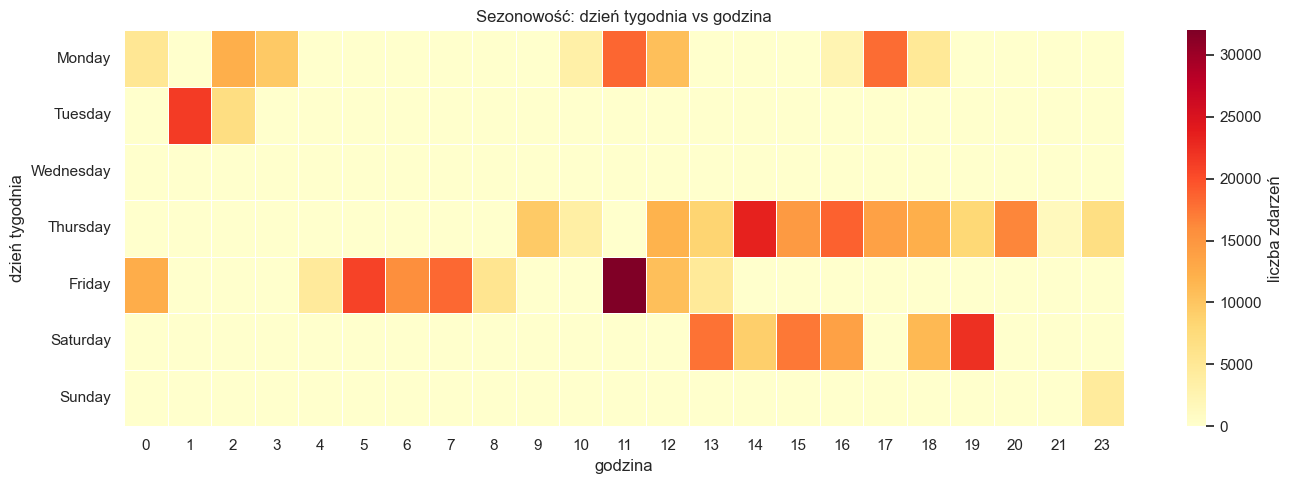

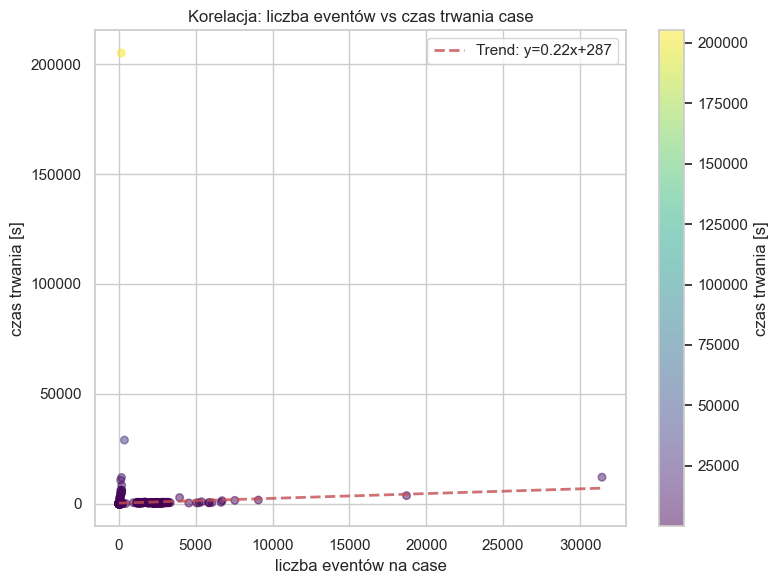

Korelacja Pearsona (eventy vs czas): 0.052


C:\Users\dusza\AppData\Local\Temp\ipykernel_2676\2600799809.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_batch_duration, x="batch", y="duration_sec", palette="Set2")


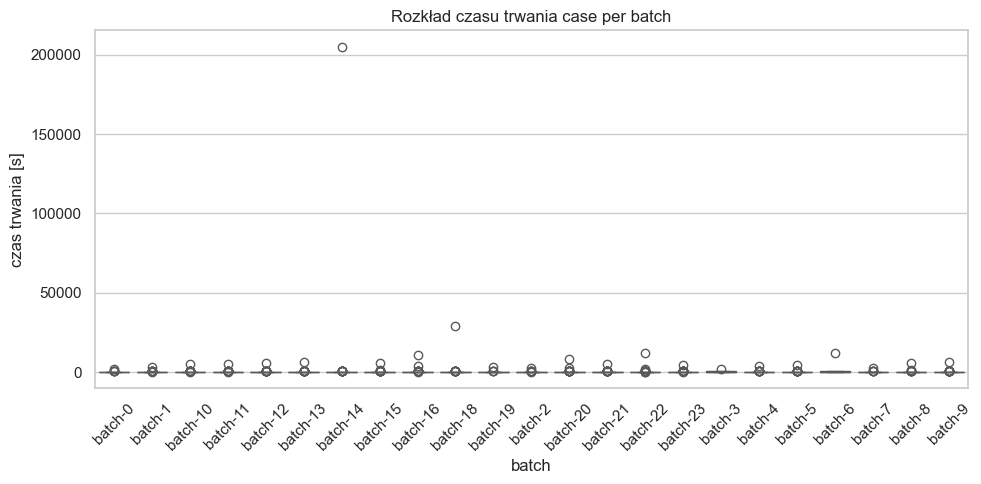


Statystyki czasu trwania per batch:
          count         mean           std       min        25%        50%         75%            max
batch                                                                                                
batch-0    29.0   166.880067    404.121786  5.491806  17.202942  30.158058   71.050144    2098.571603
batch-1    36.0   187.156065    527.683423  5.446518  18.804669  33.282217   85.482169    3136.045110
batch-10   73.0   160.658578    571.411298  5.532505  19.839480  35.844275   98.496070    4820.550298
batch-11   77.0   153.382449    592.050502  5.501711  19.839223  34.952040   90.338820    5163.036510
batch-12   78.0   176.484137    675.449253  5.537802  19.846456  33.506451   83.598191    5887.583133
batch-13   75.0   192.250607    706.490862  5.552751  24.184839  38.216820  108.495588    6060.403236
batch-14   62.0  3407.869399  26038.150429  3.726642  19.577435  28.003341   71.624278  205121.405661
batch-15   65.0   200.093809    750.841370  3

In [8]:
# Heatmapa: dzień tygodnia vs godzina (sezonowość)
if timeline_hourly:
    df_time_heatmap = pd.DataFrame({
        'timestamp': list(timeline_hourly.keys()),
        'count': list(timeline_hourly.values())
    })
    df_time_heatmap['dow'] = df_time_heatmap['timestamp'].dt.day_name()
    df_time_heatmap['hour'] = df_time_heatmap['timestamp'].dt.hour

    heat = pd.crosstab(df_time_heatmap['dow'], df_time_heatmap['hour'], 
                       values=df_time_heatmap['count'], aggfunc='sum').fillna(0)
    ordered_days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
    heat = heat.reindex(ordered_days).fillna(0)

    plt.figure(figsize=(14, 5))
    sns.heatmap(heat, cmap="YlOrRd", linewidths=0.5, cbar_kws={'label': 'liczba zdarzeń'})
    plt.title("Sezonowość: dzień tygodnia vs godzina")
    plt.xlabel("godzina")
    plt.ylabel("dzień tygodnia")
    plt.tight_layout()
    plt.show()

# Scatterplot: liczba eventów vs czas trwania case
# POPRAWKA: budujemy DataFrame przez wspólny klucz case_key, żeby uniknąć
# przesunięcia indeksów (events_per_case obejmuje wszystkie cases, a
# durations_series tylko te z timestampami – rozmiary mogą się różnić).
if case_events and case_min_ts:
    duration_map = {
        k: (case_max_ts[k] - case_min_ts[k]).total_seconds()
        for k in case_events
        if k in case_min_ts and k in case_max_ts
    }
    scatter_df = pd.DataFrame({
        'events': [case_events[k] for k in duration_map],
        'duration': list(duration_map.values())
    }).dropna()

    plt.figure(figsize=(8, 6))
    plt.scatter(scatter_df['events'], scatter_df['duration'], alpha=0.5, s=30, c=scatter_df['duration'], cmap='viridis')
    plt.xlabel("liczba eventów na case")
    plt.ylabel("czas trwania [s]")
    plt.title("Korelacja: liczba eventów vs czas trwania case")
    plt.colorbar(label="czas trwania [s]")
    
    # Dodaj linię trendu
    z = np.polyfit(scatter_df['events'].dropna(), scatter_df['duration'].dropna(), 1)
    p = np.poly1d(z)
    plt.plot(scatter_df['events'].sort_values(), p(scatter_df['events'].sort_values()), 
             "r--", alpha=0.8, linewidth=2, label=f"Trend: y={z[0]:.2f}x+{z[1]:.0f}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Statystyka korelacji
    corr = scatter_df['events'].corr(scatter_df['duration'])
    print(f"Korelacja Pearsona (eventy vs czas): {corr:.3f}")

# Boxplot: rozkład czasu trwania case per batch
if not durations_series.empty and case_batch:
    # Zbuduj DataFrame z duration per batch używając case_batch
    duration_map = {
        k: (case_max_ts[k] - case_min_ts[k]).total_seconds()
        for k in case_events
        if k in case_min_ts and k in case_max_ts
    }
    df_batch_duration_list = []
    for case_key, duration_sec in duration_map.items():
        batch_name = case_batch.get(case_key, "unknown")
        df_batch_duration_list.append({"batch": batch_name, "duration_sec": duration_sec})

    if df_batch_duration_list:
        df_batch_duration = pd.DataFrame(df_batch_duration_list)
        
        plt.figure(figsize=(10, 5))
        sns.boxplot(data=df_batch_duration, x="batch", y="duration_sec", palette="Set2")
        plt.title("Rozkład czasu trwania case per batch")
        plt.xlabel("batch")
        plt.ylabel("czas trwania [s]")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

        # Statystyka per batch
        print("\nStatystyki czasu trwania per batch:")
        print(df_batch_duration.groupby("batch")["duration_sec"].describe())



## 8. Analiza danych sensorowych 

W tym kroku analizujemy dane pomiarowe z plików `*-process.yaml` (strumienie `stream:datastream`).

Zakres:
- identyfikacja sensorów i źródeł (`stream:id`, `stream:source`, grupy datastream),
- jakość danych sensorowych (braki czasu, nienumeryczne wartości, duplikaty),
- podstawowe statystyki i wizualizacje (frequency, distribution, timeline).

Analizowane pliki process: 33
Liczba rekordów sensorowych: 38207

=== PODSTAWOWE STATYSTYKI SENSORÓW ===
{'n_sensor_records': 38207, 'n_cases': 33, 'n_sensor_types': 11, 'n_sensor_groups': 7, 'n_batches': 6}

=== JAKOŚĆ DANYCH SENSOROWYCH ===
{'missing_sensor_timestamp': 0, 'missing_sensor_id': 60, 'non_numeric_sensor_value': 303, 'duplicate_sensor_points': 81}
Duplikaty sensorowe są liczone po kombinacji case_id, sensor_id, timestamp, wartość i plik źródłowy.
Przykładowe zduplikowane rekordy sensorowe:
                             case_id sensor_id                 sensor_timestamp                             sensor_value_raw        file_name  row_index
1309739f-950b-4d9e-8ff5-e45f86b0e549       NaN 2025-07-28 02:18:11.292897+00:00 Probe  Line 4: undefined method '[]' for nil 1-1-process.yaml       9234
1309739f-950b-4d9e-8ff5-e45f86b0e549       NaN 2025-07-28 02:18:11.327785+00:00 Probe  Line 4: undefined method '[]' for nil 1-1-process.yaml       9235
1309739f-950b-4d9e-8ff5-e45f86b0

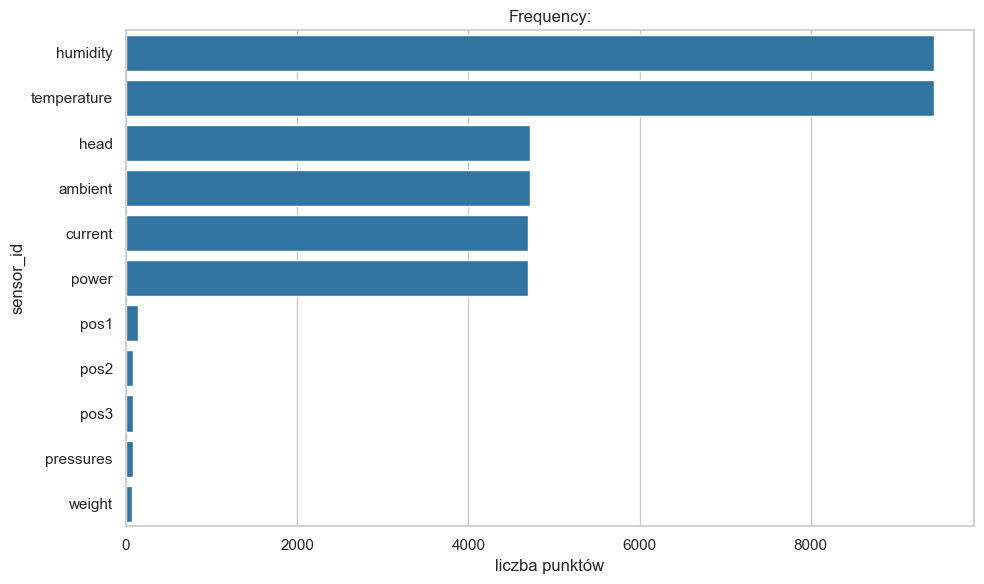

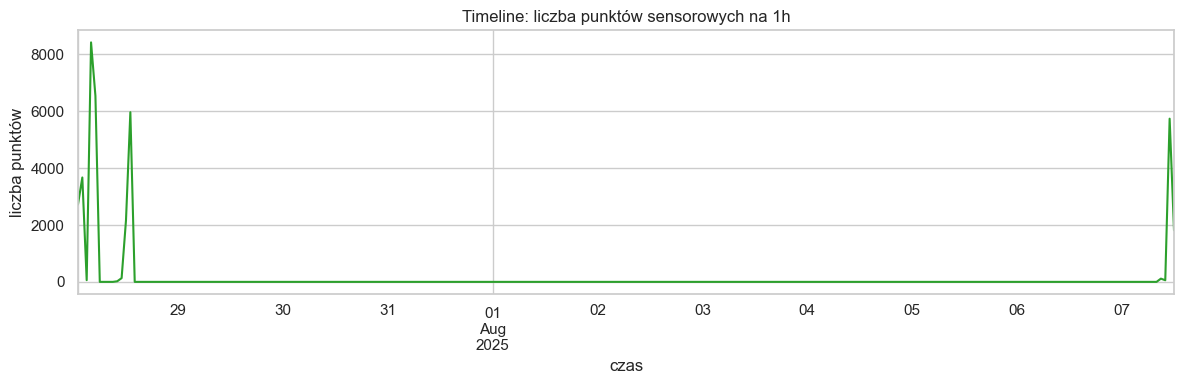

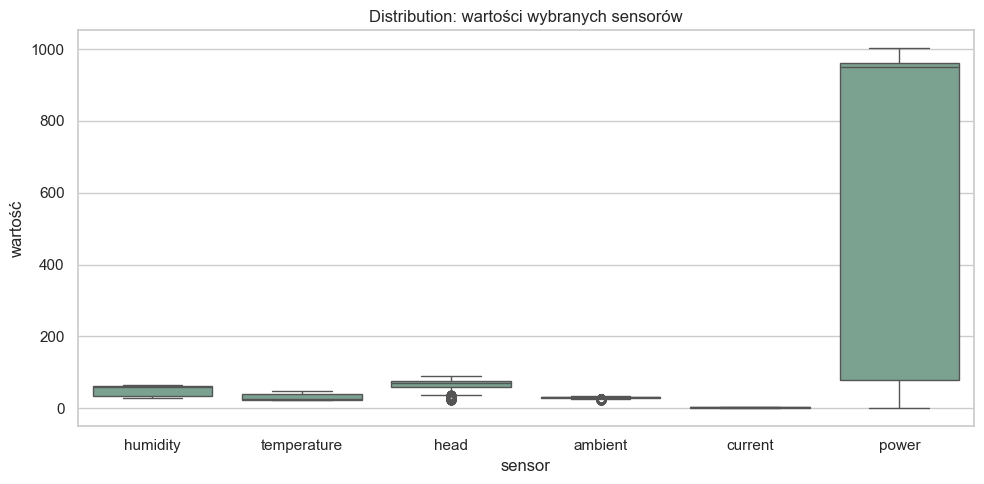


Percentyle (P50/P90/P99) dla wybranych sensorów:
                 p50      p90       p99
sensor_id                              
ambient       31.110   32.790   33.6068
current        4.355    4.403    4.4280
head          71.030   79.978   85.0972
humidity      60.130   62.950   64.8900
power        950.000  970.000  978.0000
temperature   24.820   42.000   44.6200


In [12]:
# 8. Analiza danych sensorowych z plików *-process.yaml (rozszerzona)
from collections import Counter

def iter_event_docs(yaml_path: Path):
    with yaml_path.open("r", encoding="utf-8") as f:
        docs = [d for d in yaml.safe_load_all(f) if isinstance(d, dict)]

    trace_case_uuid = None
    if docs and "log" in docs[0]:
        trace_case_uuid = (docs[0].get("log", {}).get("trace", {}) or {}).get("cpee:instance")

    for doc in docs[1:]:
        event = doc.get("event")
        if isinstance(event, dict):
            yield event, trace_case_uuid

def walk_datastream(node, current_group=None, current_source=None):
    if isinstance(node, list):
        local_group = current_group
        local_source = current_source

        for item in node:
            if isinstance(item, dict):
                local_group = item.get("stream:name", local_group)
                local_source = item.get("stream:source", local_source)

        for item in node:
            yield from walk_datastream(item, local_group, local_source)
        return

    if isinstance(node, dict):
        local_group = node.get("stream:name", current_group)
        local_source = node.get("stream:source", current_source)

        if "stream:point" in node:
            yield from walk_datastream(node["stream:point"], local_group, local_source)

        if "stream:id" in node and "stream:value" in node:
            yield {
                "sensor_group": local_group,
                "sensor_source": node.get("stream:source", local_source),
                "sensor_id": node.get("stream:id"),
                "sensor_timestamp_raw": node.get("stream:timestamp"),
                "sensor_value_raw": node.get("stream:value"),
            }

        for key, value in node.items():
            if key == "stream:point":
                continue
            if isinstance(value, (dict, list)):
                yield from walk_datastream(value, local_group, local_source)

sensor_rows = []
process_yaml_files = sorted(DATA_DIR.glob("batch-*/*-process.yaml"))

print(f"Analizowane pliki process: {len(process_yaml_files)}")

for process_path in process_yaml_files:
    batch_name = process_path.parent.name
    for event, trace_case_uuid in iter_event_docs(process_path):
        case_id = event.get("cpee:instance") or trace_case_uuid
        event_name = event.get("concept:name")
        event_endpoint = event.get("concept:endpoint")
        event_time = pd.to_datetime(event.get("time:timestamp"), errors="coerce", utc=True)

        datastream = event.get("stream:datastream")
        if datastream is None:
            continue

        for point in walk_datastream(datastream):
            sensor_time = pd.to_datetime(point["sensor_timestamp_raw"], errors="coerce", utc=True)
            sensor_value_num = pd.to_numeric(point["sensor_value_raw"], errors="coerce")

            sensor_rows.append({
                "case_id": case_id,
                "batch": batch_name,
                "file_name": process_path.name,
                "event_name": event_name,
                "event_endpoint": event_endpoint,
                "event_time": event_time,
                "sensor_group": point["sensor_group"],
                "sensor_source": point["sensor_source"],
                "sensor_id": point["sensor_id"],
                "sensor_timestamp": sensor_time,
                "sensor_value_raw": point["sensor_value_raw"],
                "sensor_value_num": sensor_value_num,
            })

df_sensors = pd.DataFrame(sensor_rows)
print("Liczba rekordów sensorowych:", len(df_sensors))

if df_sensors.empty:
    print("Brak punktów sensorowych do analizy.")
else:
    # Czyszczenie minimalne
    df_sensors["sensor_id"] = df_sensors["sensor_id"].astype(str).str.strip()
    df_sensors.loc[df_sensors["sensor_id"].isin(["", "None", "nan"]), "sensor_id"] = np.nan
    df_sensors["sensor_value_num_clean"] = pd.to_numeric(df_sensors["sensor_value_num"], errors="coerce")

    print("\n=== PODSTAWOWE STATYSTYKI SENSORÓW ===")
    print({
        "n_sensor_records": len(df_sensors),
        "n_cases": df_sensors["case_id"].nunique(dropna=True),
        "n_sensor_types": df_sensors["sensor_id"].nunique(dropna=True),
        "n_sensor_groups": df_sensors["sensor_group"].nunique(dropna=True),
        "n_batches": df_sensors["batch"].nunique(dropna=True),
    })

    # Jakość danych sensorowych
    missing_ts = df_sensors["sensor_timestamp"].isna().sum()
    missing_id = df_sensors["sensor_id"].isna().sum()
    non_numeric = df_sensors["sensor_value_num_clean"].isna().sum()
    dup_key = (
        df_sensors["case_id"].astype(str)
        + "|" + df_sensors["sensor_id"].astype(str)
        + "|" + df_sensors["sensor_timestamp"].astype(str)
        + "|" + df_sensors["sensor_value_raw"].map(lambda x: repr(x))
        + "|" + df_sensors["file_name"].astype(str)
    )
    duplicates = dup_key.duplicated().sum()
    dup_mask = dup_key.duplicated(keep=False)

    print("\n=== JAKOŚĆ DANYCH SENSOROWYCH ===")
    print({
        "missing_sensor_timestamp": int(missing_ts),
        "missing_sensor_id": int(missing_id),
        "non_numeric_sensor_value": int(non_numeric),
        "duplicate_sensor_points": int(duplicates),
    })
    print("Duplikaty sensorowe są liczone po kombinacji case_id, sensor_id, timestamp, wartość i plik źródłowy.")
    if dup_mask.any():
        dup_preview = (
            df_sensors.loc[dup_mask, ["case_id", "sensor_id", "sensor_timestamp", "sensor_value_raw", "file_name"]]
            .copy()
            .assign(row_index=lambda x: x.index)
            .sort_values(["case_id", "sensor_id", "sensor_timestamp", "sensor_value_raw", "file_name"])
        )
        print("Przykładowe zduplikowane rekordy sensorowe:")
        print(dup_preview.head(20).to_string(index=False))
        print("Najczęstsze powtórzone wartości klucza sensorowego:")
        print(dup_key[dup_mask].value_counts().head(10))

    print("\nNajczęstsze sensory:")
    sensor_freq = df_sensors["sensor_id"].dropna().value_counts()
    print(sensor_freq.head(15))

    # Rozbicie jakości per sensor
    quality_by_sensor = (
        df_sensors.groupby("sensor_id", dropna=False)
        .agg(
            records=("sensor_id", "size"),
            missing_timestamp=("sensor_timestamp", lambda s: s.isna().sum()),
            non_numeric_value=("sensor_value_num_clean", lambda s: s.isna().sum()),
        )
        .sort_values("records", ascending=False)
    )
    print("\nJakość danych dla każdego sensora:")
    print(quality_by_sensor.head(15))

    # Statystyki numeryczne
    numeric_stats = (
        df_sensors.dropna(subset=["sensor_id", "sensor_value_num_clean"])
        .groupby("sensor_id")["sensor_value_num_clean"]
        .describe()
        [["count", "mean", "std", "min", "25%", "50%", "75%", "max"]]
        .sort_values("count", ascending=False)
    )
    print("\nStatystyki wartości numerycznych dla każdego sensora:")
    print(numeric_stats.head(15))

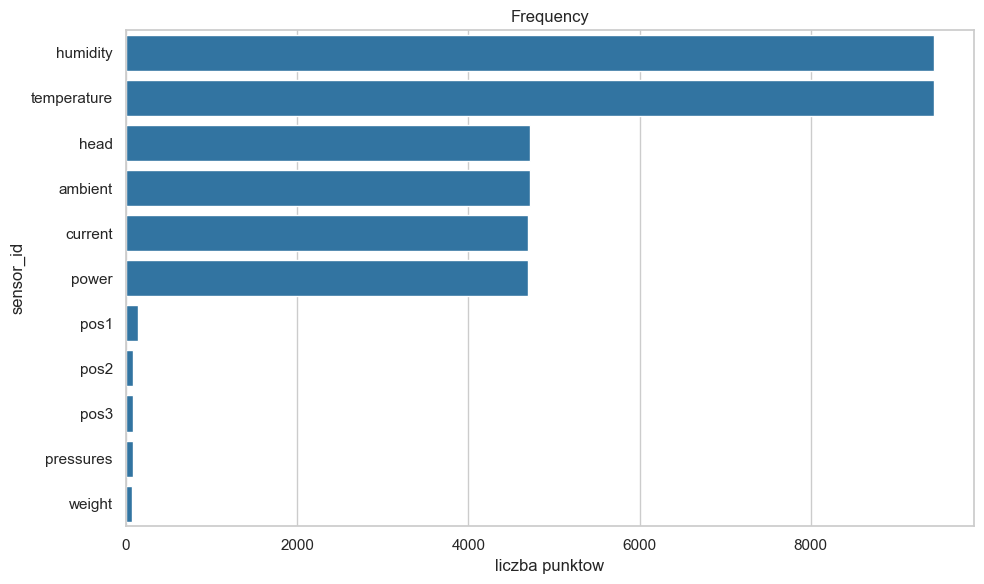

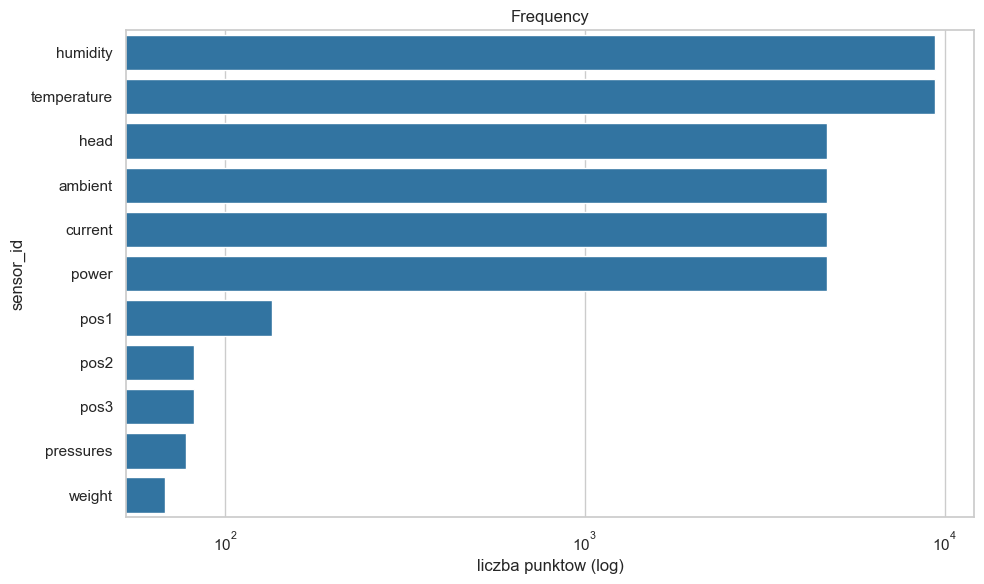

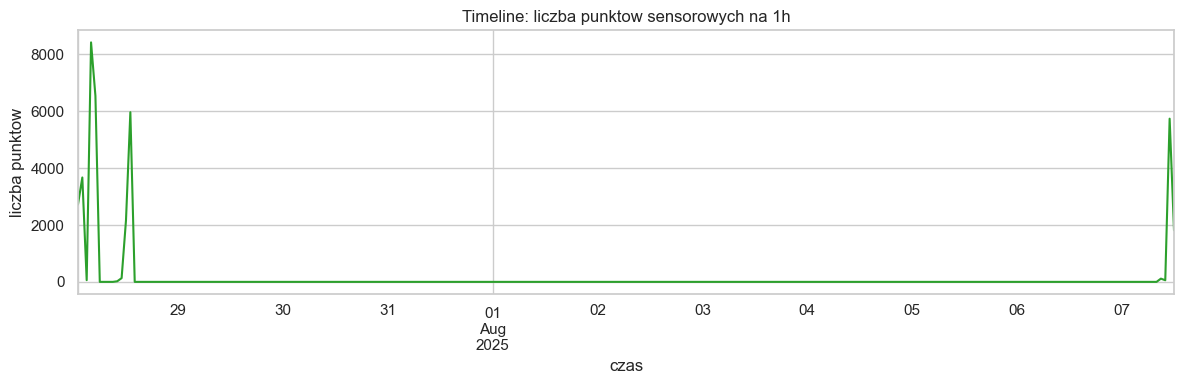

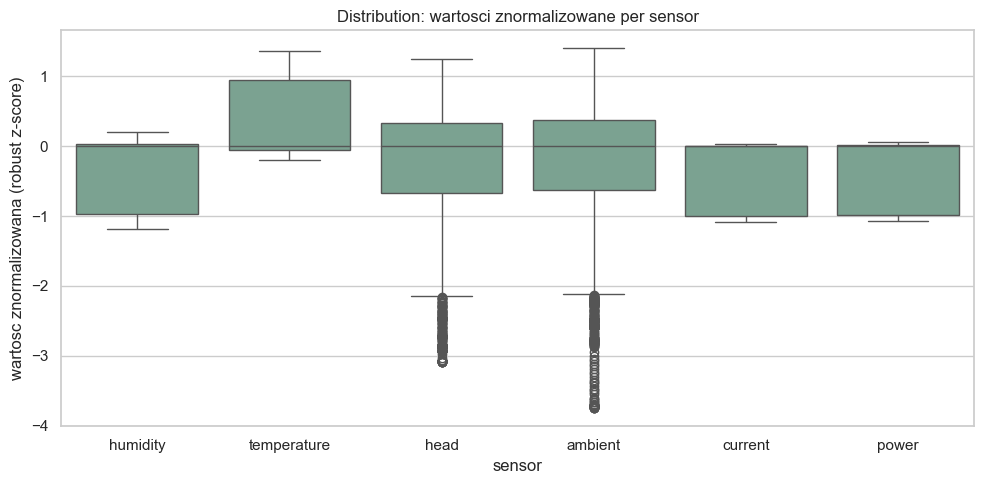

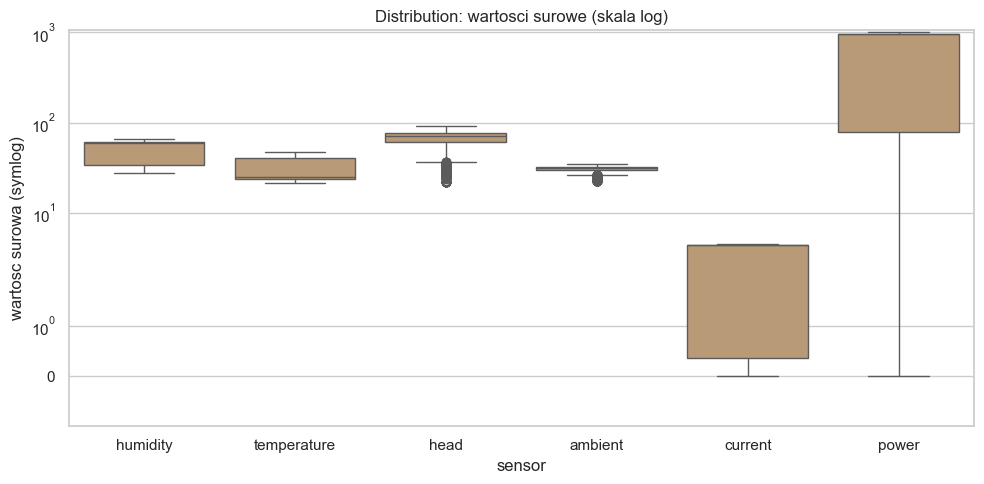


Percentyle (P50/P90/P99) dla wybranych sensorow:
                 p50      p90       p99
sensor_id                              
ambient       31.110   32.790   33.6068
current        4.355    4.403    4.4280
head          71.030   79.978   85.0972
humidity      60.130   62.950   64.8900
power        950.000  970.000  978.0000
temperature   24.820   42.000   44.6200


In [21]:
# 8.1 Wizualizacje sensorow (bez ponownego wczytywania plikow)
if "df_sensors" not in globals() or df_sensors.empty:
    raise ValueError("Brak df_sensors. Uruchom sekcje 8 przed wizualizacjami.")

# Frequency (skala liniowa)
sensor_freq = df_sensors["sensor_id"].dropna().value_counts()
plt.figure(figsize=(10, 6))
sns.barplot(x=sensor_freq.head(15).values, y=sensor_freq.head(15).index, orient="h", color="#1f77b4")
plt.title("Frequency")
plt.xlabel("liczba punktow")
plt.ylabel("sensor_id")
plt.tight_layout()
plt.show()

# Frequency (alternatywa: skala log na osi X)
plt.figure(figsize=(10, 6))
sns.barplot(x=sensor_freq.head(15).values, y=sensor_freq.head(15).index, orient="h", color="#1f77b4")
plt.xscale("log")
plt.title("Frequency")
plt.xlabel("liczba punktow (log)")
plt.ylabel("sensor_id")
plt.tight_layout()
plt.show()

# Timeline
sensor_time = df_sensors["sensor_timestamp"].dropna()
if not sensor_time.empty:
    sensor_time = sensor_time.sort_values()
    q_low, q_high = sensor_time.quantile([0.01, 0.99])
    sensor_time_clip = sensor_time[(sensor_time >= q_low) & (sensor_time <= q_high)]
    if sensor_time_clip.empty:
        sensor_time_clip = sensor_time
    time_span_days = (sensor_time_clip.max() - sensor_time_clip.min()).total_seconds() / 86400
    freq = "1h" if time_span_days <= 14 else "1d"
    sensor_time_series = (
        sensor_time_clip.to_frame(name="ts")
        .set_index("ts")
        .resample(freq)
        .size()
    )
    if not sensor_time_series.empty:
        plt.figure(figsize=(12, 4))
        sensor_time_series.plot(color="#2ca02c")
        plt.title(f"Timeline: liczba punktow sensorowych na {freq}")
        plt.xlabel("czas")
        plt.ylabel("liczba punktow")
        plt.tight_layout()
        plt.show()

# Distribution (znormalizowane per sensor, aby uniknac dominacji pojedynczych typow)
selected_sensors = [
    s for s in ["temperature", "humidity", "ambient", "head", "power", "current"]
    if s in set(df_sensors["sensor_id"].dropna())
]
if selected_sensors:
    plot_df = df_sensors[df_sensors["sensor_id"].isin(selected_sensors)].dropna(subset=["sensor_value_num_clean"]).copy()
    if not plot_df.empty:
        def robust_zscore(series: pd.Series) -> pd.Series:
            q1 = series.quantile(0.25)
            q3 = series.quantile(0.75)
            iqr = q3 - q1
            if iqr == 0 or pd.isna(iqr):
                std = series.std()
                if std == 0 or pd.isna(std):
                    return series * 0
                return (series - series.mean()) / std
            return (series - series.median()) / iqr

        plot_df["value_norm"] = plot_df.groupby("sensor_id")["sensor_value_num_clean"].transform(robust_zscore)
        plt.figure(figsize=(10, 5))
        sns.boxplot(data=plot_df, x="sensor_id", y="value_norm", color="#74a892")
        plt.title("Distribution: wartosci znormalizowane per sensor")
        plt.xlabel("sensor")
        plt.ylabel("wartosc znormalizowana (robust z-score)")
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(10, 5))
        sns.boxplot(data=plot_df, x="sensor_id", y="sensor_value_num_clean", color="#c49a6c")
        plt.yscale("symlog")
        plt.title("Distribution: wartosci surowe (skala log)")
        plt.xlabel("sensor")
        plt.ylabel("wartosc surowa (symlog)")
        plt.ylim(bottom=-1)  # unika problemow z log(0)
        plt.tight_layout()
        plt.show()

        print("\nPercentyle (P50/P90/P99) dla wybranych sensorow:")
        summary = (
            plot_df.groupby("sensor_id")["sensor_value_num_clean"]
            .quantile([0.5, 0.9, 0.99])
            .unstack()
            .rename(columns={0.5: "p50", 0.9: "p90", 0.99: "p99"})
        )
        print(summary)

In [26]:
# 8.2 Diagnostyka timeline sensorow (dlaczego sa duze przerwy)
if "df_sensors" not in globals() or df_sensors.empty:
    raise ValueError("Brak df_sensors. Uruchom sekcje 8 przed diagnostyka timeline.")

sensor_time_diag = df_sensors["sensor_timestamp"].dropna().sort_values()
print("Zakres czasu sensorow:")
print("- min:", sensor_time_diag.min())
print("- max:", sensor_time_diag.max())

if len(sensor_time_diag) >= 2:
    gaps = sensor_time_diag.diff().dropna()
    print("\nStatystyki przerw (sekundy):")
    print(gaps.dt.total_seconds().describe())

    # Najwieksze przerwy
    top_gaps = gaps.sort_values(ascending=False).head(10)
    print("\nTop 10 najwiekszych przerw:")
    for idx, gap in top_gaps.items():
        end_ts = sensor_time_diag.loc[idx]
        start_ts = end_ts - gap
        print(f"- przerwa {gap} od {start_ts} do {end_ts}")

    # Ile punktow jest w danej dobie (szybka kontrola 'dziur')
    per_day = sensor_time_diag.dt.floor("D").value_counts().sort_index()
    print("\nPunkty sensorowe per dzien (pierwsze/ostatnie 5):")
    print(pd.concat([per_day.head(5), per_day.tail(5)]))
else:
    print("Za malo punktow czasu do analizy przerw.")

Zakres czasu sensorow:
- min: 2025-07-27 23:49:24.468771+00:00
- max: 2025-08-07 12:19:47.990000+00:00

Statystyki przerw (sekundy):
count     38206.000000
mean         23.792690
std        4334.859450
min           0.000000
25%           0.000000
50%           0.000000
75%           0.050000
max      847087.158898
Name: sensor_timestamp, dtype: float64

Top 10 najwiekszych przerw:
- przerwa 9 days 19:18:07.158898 od 2025-07-28 13:54:34.930000+00:00 do 2025-08-07 09:12:42.088898+00:00
- przerwa 0 days 04:59:40.808518 od 2025-07-28 05:33:57.200000+00:00 do 2025-07-28 10:33:38.008518+00:00
- przerwa 0 days 01:28:14.716745 od 2025-07-28 00:16:23.733255+00:00 do 2025-07-28 01:44:38.450000+00:00
- przerwa 0 days 00:49:31.075396 od 2025-08-07 10:18:36.064604+00:00 do 2025-08-07 11:08:07.140000+00:00
- przerwa 0 days 00:35:14.476808 od 2025-07-28 11:53:25.373192+00:00 do 2025-07-28 12:28:39.850000+00:00
- przerwa 0 days 00:32:02.608777 od 2025-07-28 03:33:43.211223+00:00 do 2025-07-28 04:05:4

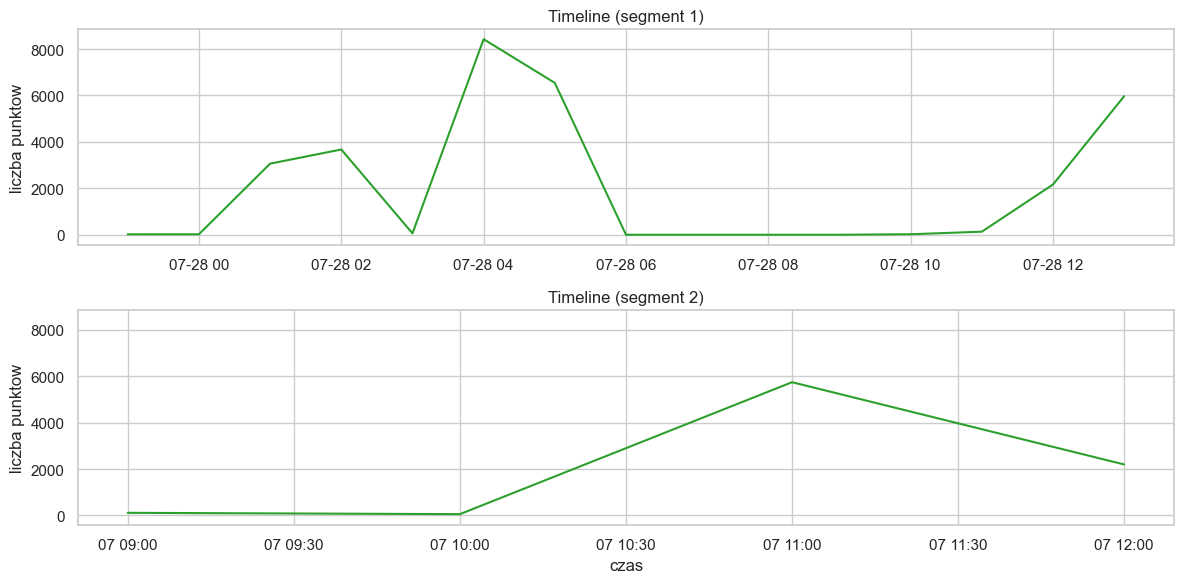

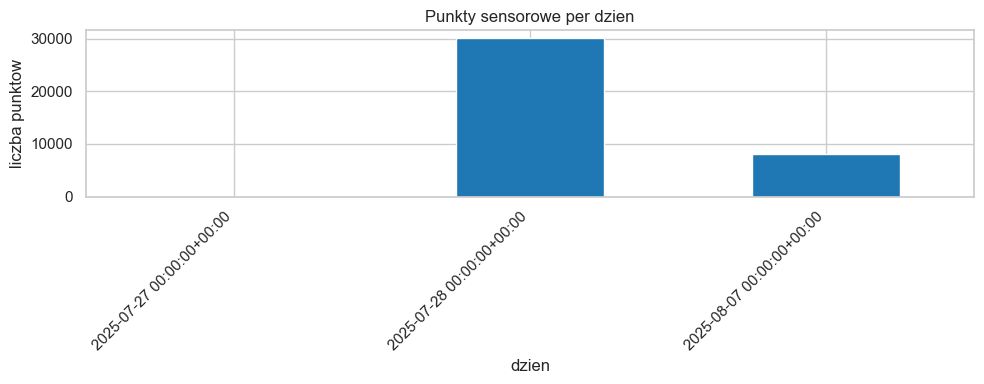

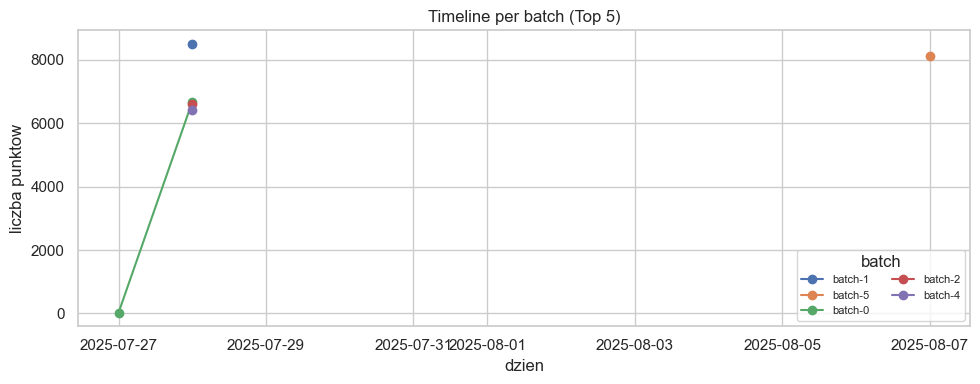

In [27]:
# 8.3 Timeline alternatywy: segmenty, per-dzien, per-batch
if "df_sensors" not in globals() or df_sensors.empty:
    raise ValueError("Brak df_sensors. Uruchom sekcje 8 przed wizualizacjami timeline.")

ts_all = df_sensors["sensor_timestamp"].dropna().sort_values()
if len(ts_all) < 2:
    print("Za malo punktow czasu do wizualizacji.")
else:
    # (1) Segmenty bez duzych przerw
    gap_threshold = pd.Timedelta("1D")
    split_points = ts_all.diff() > gap_threshold
    segment_ids = split_points.cumsum()
    segments = [seg for _, seg in ts_all.groupby(segment_ids)]
    max_segments = min(len(segments), 6)
    if max_segments > 0:
        fig, axes = plt.subplots(max_segments, 1, figsize=(12, 3 * max_segments), sharey=True)
        if max_segments == 1:
            axes = [axes]
        for i in range(max_segments):
            seg = segments[i]
            seg_series = (
                seg.to_frame(name="ts")
                .set_index("ts")
                .resample("1h")
                .size()
            )
            axes[i].plot(seg_series.index, seg_series.values, color="#2ca02c")
            axes[i].set_title(f"Timeline (segment {i + 1})")
            axes[i].set_ylabel("liczba punktow")
        axes[-1].set_xlabel("czas")
        plt.tight_layout()
        plt.show()

    # (2) Per-dzien (barplot)
    per_day = ts_all.dt.floor("D").value_counts().sort_index()
    plt.figure(figsize=(10, 4))
    per_day.plot(kind="bar", color="#1f77b4")
    plt.title("Punkty sensorowe per dzien")
    plt.xlabel("dzien")
    plt.ylabel("liczba punktow")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    # (3) Per-batch (linia dzienna dla top batchy)
    df_batch = df_sensors.dropna(subset=["sensor_timestamp", "batch"]).copy()
    if not df_batch.empty:
        df_batch["day"] = df_batch["sensor_timestamp"].dt.floor("D")
        top_batches = df_batch["batch"].value_counts().head(5).index.tolist()
        batch_series = (
            df_batch[df_batch["batch"].isin(top_batches)]
            .groupby(["batch", "day"])
            .size()
            .reset_index(name="count")
        )
        plt.figure(figsize=(10, 4))
        for batch_name in top_batches:
            sub = batch_series[batch_series["batch"] == batch_name]
            plt.plot(sub["day"], sub["count"], marker="o", label=batch_name)
        plt.title("Timeline per batch (Top 5)")
        plt.xlabel("dzien")
        plt.ylabel("liczba punktow")
        plt.legend(title="batch", ncol=2, fontsize=8)
        plt.tight_layout()
        plt.show()

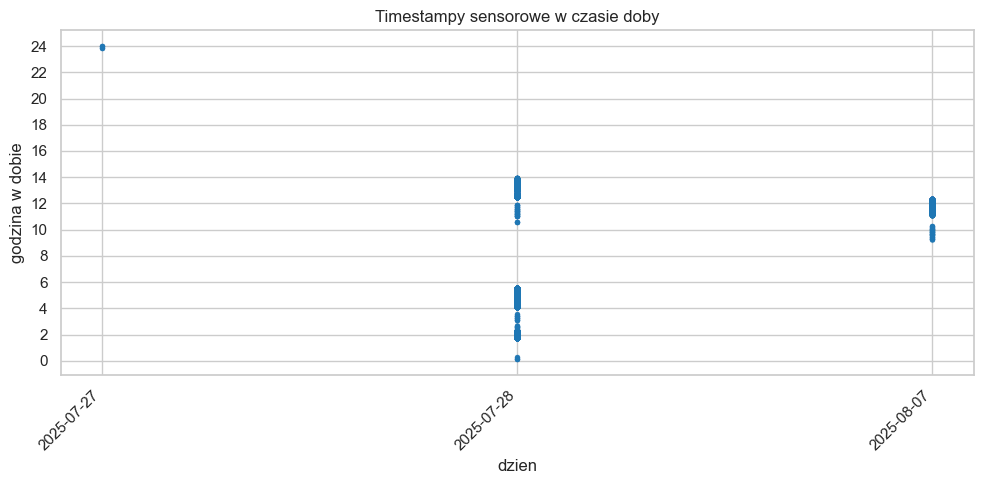

In [31]:
# 8.4 Timestampy dla kazdego dnia (rozklad w czasie doby)
if "df_sensors" not in globals() or df_sensors.empty:
    raise ValueError("Brak df_sensors. Uruchom sekcje 8 przed wykresem timestampow.")

ts_points = df_sensors["sensor_timestamp"].dropna().copy()
if ts_points.empty:
    print("Brak timestampow do wykresu.")
else:
    # Downsampling dla czytelnosci, jesli punktow jest bardzo duzo
    max_points = 20000
    if len(ts_points) > max_points:
        ts_points = ts_points.sample(n=max_points, random_state=42)
    ts_points = ts_points.sort_values()

    df_ts = pd.DataFrame({
        "day": ts_points.dt.floor("D"),
        "time_of_day": ts_points.dt.hour + ts_points.dt.minute / 60 + ts_points.dt.second / 3600,
    })

    # Tylko dni z danymi: oś X jako kolejne indeksy, etykiety jako daty
    day_order = df_ts["day"].drop_duplicates().sort_values().reset_index(drop=True)
    day_to_idx = {day: i for i, day in enumerate(day_order)}
    df_ts["day_idx"] = df_ts["day"].map(day_to_idx)

    plt.figure(figsize=(10, 5))
    plt.scatter(df_ts["day_idx"], df_ts["time_of_day"], s=8, alpha=0.4, color="#1f77b4")
    plt.title("Timestampy sensorowe w czasie doby")
    plt.xlabel("dzien")
    plt.ylabel("godzina w dobie")
    plt.yticks(range(0, 25, 2))

    # Etykiety osi X bez pustych dni
    tick_idx = list(range(len(day_order)))
    tick_labels = [d.strftime("%Y-%m-%d") for d in day_order]
    plt.xticks(tick_idx, tick_labels, rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## 9. Modele BPMN w datasecie (bpmn.io + interpretacja)

Jeśli dataset zawiera gotowe modele BPMN, należy je zwizualizować i opisać.

Poniżej:
- automatyczne wyszukanie XML-i BPMN w logach,
- zapis znalezionych modeli do plików `.bpmn`,
- podstawowa analiza struktury modelu (taski, eventy, gatewaye, sequence flow),
- link do bpmn.io (import pliku ręcznie).

In [15]:
# 9. Wyszukiwanie modeli BPMN i ich analiza
import xml.etree.ElementTree as ET

def extract_xml_candidates(event_dict):
    candidates = []
    for key in ["cpee:description", "cpee_description", "description", "model", "bpmn"]:
        val = event_dict.get(key)
        if isinstance(val, str) and "<" in val and ">" in val:
            candidates.append((key, val))
    return candidates

def is_bpmn_xml(xml_text):
    low = xml_text.lower()
    return ("bpmn" in low and "<" in low and ">" in low and ("definitions" in low or "process" in low))

def bpmn_element_stats(xml_text):
    root = ET.fromstring(xml_text)
    counts = Counter()
    for el in root.iter():
        tag = el.tag.split("}")[-1] if "}" in el.tag else el.tag
        counts[tag] += 1

    task_like = sum(counts[k] for k in counts if k.lower().endswith("task"))
    event_like = sum(counts[k] for k in counts if k.lower().endswith("event"))
    gateway_like = sum(counts[k] for k in counts if k.lower().endswith("gateway"))
    sequence_flows = counts.get("sequenceFlow", 0)

    return {
        "elements_total": int(sum(counts.values())),
        "task_like": int(task_like),
        "event_like": int(event_like),
        "gateway_like": int(gateway_like),
        "sequenceFlow": int(sequence_flows),
    }

bpmn_output_dir = BASE_DIR / "reports" / "milestone1" / "bpmn_models"
bpmn_output_dir.mkdir(parents=True, exist_ok=True)

candidate_files = sorted(DATA_DIR.glob("batch-*/*.xes.yaml")) + sorted(DATA_DIR.glob("batch-*/*-process.yaml"))
found_bpmn = []
found_non_bpmn_xml = []

for fpath in candidate_files:
    with fpath.open("r", encoding="utf-8") as f:
        docs = [d for d in yaml.safe_load_all(f) if isinstance(d, dict)]
    for doc in docs[1:]:
        event = doc.get("event")
        if not isinstance(event, dict):
            continue
        for source_key, xml_text in extract_xml_candidates(event):
            if is_bpmn_xml(xml_text):
                found_bpmn.append({
                    "file": str(fpath.relative_to(BASE_DIR)).replace("\\", "/"),
                    "source_key": source_key,
                    "xml_text": xml_text,
                })
            else:
                # Mamy XML, ale nie BPMN (np. opis CPEE)
                found_non_bpmn_xml.append({
                    "file": str(fpath.relative_to(BASE_DIR)).replace("\\", "/"),
                    "source_key": source_key,
                    "xml_text": xml_text,
                })

print("Znalezione BPMN XML:", len(found_bpmn))

if found_bpmn:
    for i, item in enumerate(found_bpmn[:5], start=1):
        out_file = bpmn_output_dir / f"model_{i}.bpmn"
        out_file.write_text(item["xml_text"], encoding="utf-8")

        try:
            stats = bpmn_element_stats(item["xml_text"])
        except Exception as ex:
            stats = {"parse_error": str(ex)}

        print(f"\nModel BPMN #{i}")
        print("Plik źródłowy:", item["file"])
        print("Zapisano do:", out_file)
        print("Statystyki:", stats)

    print("\nAby zwizualizować model w bpmn.io:")
    print("1) Otwórz: https://demo.bpmn.io/")
    print("2) Wybierz Open from File i wskaż plik z reports/milestone1/bpmn_models/")
else:
    print("Brak gotowych modeli BPMN w logach.")
    if found_non_bpmn_xml:
        print("Znaleziono XML-e nie-BPMN (np. opisy procesu CPEE).")
        preview = pd.DataFrame(found_non_bpmn_xml)[["file", "source_key"]].drop_duplicates().head(10)
        print(preview)
        print("Te XML-e opisują workflow CPEE, ale nie są bezpośrednio BPMN do bpmn.io.")

Znalezione BPMN XML: 0
Brak gotowych modeli BPMN w logach.
Znaleziono XML-e nie-BPMN (np. opisy procesu CPEE).
                                                file        source_key
0  cotton-candy/batch-0/028e282d-26a3-4ae8-909e-a...  cpee:description
1  cotton-candy/batch-0/05d1aced-493d-4865-b52a-2...  cpee:description
2  cotton-candy/batch-0/297e0617-0aef-4021-a4e4-8...  cpee:description
3  cotton-candy/batch-0/35687645-77fc-477e-8fa2-8...  cpee:description
4  cotton-candy/batch-0/47c62abe-5c90-4533-93f2-7...  cpee:description
5  cotton-candy/batch-0/49857f45-1f53-403e-9947-f...  cpee:description
6  cotton-candy/batch-0/4c78afba-612e-413a-bab6-b...  cpee:description
7  cotton-candy/batch-0/4fb7d89b-3787-479c-9046-9...  cpee:description
8  cotton-candy/batch-0/4fc97e9c-ecda-4a67-b3fc-1...  cpee:description
9  cotton-candy/batch-0/5bfa0cf3-4b69-419d-a6bb-b...  cpee:description
Te XML-e opisują workflow CPEE, ale nie są bezpośrednio BPMN do bpmn.io.


## 11. Heatmapa jakości sensorów + eksport tabel do CSV

Sekcję rozdzielamy na:
- **11.1** – generowanie heatmapy jakości sensorów,
- **11.2** – eksport tabel do CSV (bez ponownego przeszukiwania danych sensorowych).

Krótki opis do raportu: heatmapa prezentuje trzy metryki jakości dla najczęściej występujących sensorów (braki timestampów, nienumeryczne wartości oraz duplikaty) w ujęciu procentowym, co pozwala szybko porównać stabilność i spójność danych między sensorami.

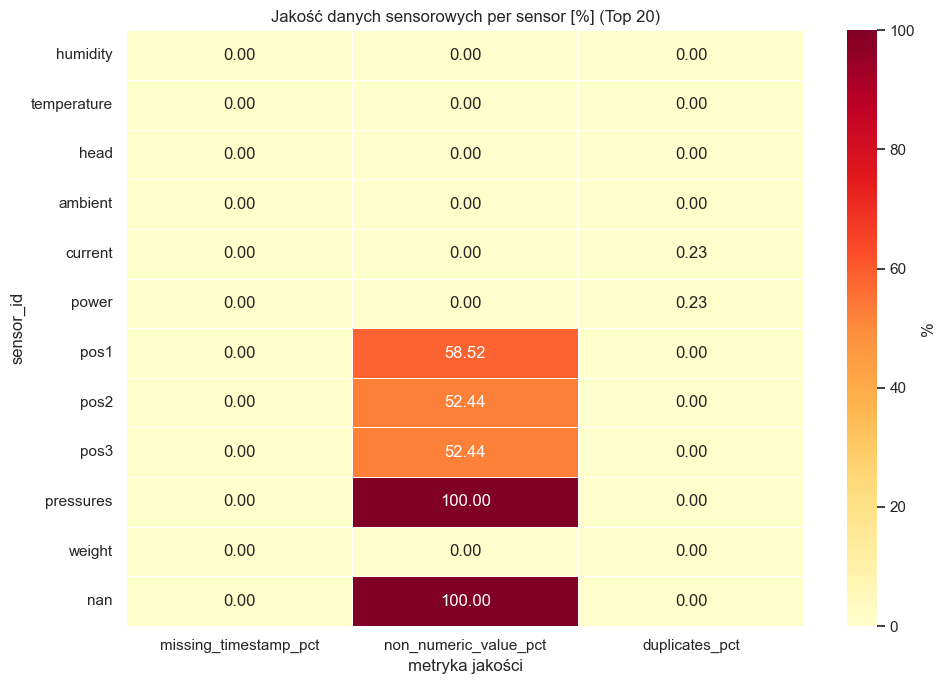

In [18]:
# 11.1 Heatmapa jakości sensorów
if "df_sensors" not in globals() or df_sensors.empty:
    raise ValueError("Brak df_sensors. Uruchom najpierw sekcję 8 (komórka 20).")

# Upewniamy się, że kolumny pomocnicze istnieją
if "sensor_value_num_clean" not in df_sensors.columns:
    df_sensors["sensor_value_num_clean"] = pd.to_numeric(df_sensors["sensor_value_num"], errors="coerce")

df_sensors_local = df_sensors.copy()
df_sensors_local["sensor_id"] = df_sensors_local["sensor_id"].astype(str).str.strip()
df_sensors_local.loc[df_sensors_local["sensor_id"].isin(["", "None", "nan"]), "sensor_id"] = np.nan

sensor_quality = (
    df_sensors_local.groupby("sensor_id", dropna=False)
    .agg(
        records=("sensor_id", "size"),
        missing_timestamp=("sensor_timestamp", lambda s: s.isna().sum()),
        non_numeric_value=("sensor_value_num_clean", lambda s: s.isna().sum()),
    )
    .sort_values("records", ascending=False)
 )

sensor_quality["missing_timestamp_pct"] = (sensor_quality["missing_timestamp"] / sensor_quality["records"] * 100).round(2)
sensor_quality["non_numeric_value_pct"] = (sensor_quality["non_numeric_value"] / sensor_quality["records"] * 100).round(2)

dup_series = (
    df_sensors_local["case_id"].astype(str)
    + "|" + df_sensors_local["sensor_id"].astype(str)
    + "|" + df_sensors_local["sensor_timestamp"].astype(str)
    + "|" + df_sensors_local["sensor_value_raw"].map(lambda x: repr(x))
    + "|" + df_sensors_local["file_name"].astype(str)
)
is_dup = dup_series.duplicated()
dup_per_sensor = df_sensors_local.loc[is_dup].groupby("sensor_id").size()
sensor_quality["duplicates"] = dup_per_sensor
sensor_quality["duplicates"] = sensor_quality["duplicates"].fillna(0).astype(int)
sensor_quality["duplicates_pct"] = (sensor_quality["duplicates"] / sensor_quality["records"] * 100).round(2)

heat_df = sensor_quality.head(20)[["missing_timestamp_pct", "non_numeric_value_pct", "duplicates_pct"]]
plt.figure(figsize=(10, 7))
sns.heatmap(heat_df, annot=True, fmt=".2f", cmap="YlOrRd", linewidths=0.5, cbar_kws={"label": "%"})
plt.title("Jakość danych sensorowych per sensor [%] (Top 20)")
plt.xlabel("metryka jakości")
plt.ylabel("sensor_id")
plt.tight_layout()
plt.show()

In [23]:
# 11.2 Eksport tabel do CSV (bez ponownego przeszukiwania danych sensorowych)
export_dir = BASE_DIR / "reports" / "milestone1"
export_dir.mkdir(parents=True, exist_ok=True)

if "df_sensors" not in globals() or df_sensors.empty:
    raise ValueError("Brak df_sensors. Uruchom najpierw sekcję 8 (komórka 20).")

if "sensor_value_num_clean" not in df_sensors.columns:
    df_sensors["sensor_value_num_clean"] = pd.to_numeric(df_sensors["sensor_value_num"], errors="coerce")

df_sensors_local = df_sensors.copy()
df_sensors_local["sensor_id"] = df_sensors_local["sensor_id"].astype(str).str.strip()
df_sensors_local.loc[df_sensors_local["sensor_id"].isin(["", "None", "nan"]), "sensor_id"] = np.nan

if "milestone1_checklist" not in globals():
    milestone1_checklist = pd.DataFrame([
        {
            "wymaganie": "Opis zbioru danych i kontekstu",
            "status": "OK",
            "pokrycie_w_notebooku": "Sekcja 1 (komórka 1) + Sekcja 7 (komórka 15)"
        },
        {
            "wymaganie": "Identyfikacja kluczowych atrybutów (case/activity/timestamp/resource)",
            "status": "OK",
            "pokrycie_w_notebooku": "Sekcja 3 (komórki 6-7) + Sekcja 7 (komórka 15)"
        },
        {
            "wymaganie": "Analiza jakości danych (braki, duplikaty, timestampy, typy)",
            "status": "OK",
            "pokrycie_w_notebooku": "Sekcja 4 (komórka 9) + Sekcja 8 (komórka 20)"
        },
        {
            "wymaganie": "Eksploracyjna analiza danych",
            "status": "OK",
            "pokrycie_w_notebooku": "Sekcja 6 (komórka 13) + Sekcja 7.3 (komórka 18) + Sekcja 8 (komórka 20)"
        },
        {
            "wymaganie": "Podstawowe statystyki (eventy, cases, activities, sensory)",
            "status": "OK",
            "pokrycie_w_notebooku": "Sekcja 5 (komórka 11) + Sekcja 8 (komórka 20)"
        },
        {
            "wymaganie": "Podstawowe wizualizacje (timeline, distribution, frequency)",
            "status": "OK",
            "pokrycie_w_notebooku": "Sekcja 6 (komórka 13) + Sekcja 8 (komórka 20)"
        },
        {
            "wymaganie": "Modele BPMN (jeśli są) + interpretacja",
            "status": "Częściowo (brak BPMN w danych)",
            "pokrycie_w_notebooku": "Sekcja 9 (komórki 21-22): automatyczne wyszukanie i analiza XML"
        },
    ])

summary_df = pd.DataFrame([
    {
        "liczba_zdarzen": len(df_events),
        "liczba_przypadkow": df_events["case_id"].nunique() if "case_id" in df_events.columns else np.nan,
        "liczba_aktywnosci": df_events["activity"].nunique() if "activity" in df_events.columns else np.nan,
        "liczba_punktow_sensorowych": len(df_sensors_local),
        "liczba_typow_sensorow": df_sensors_local["sensor_id"].nunique(dropna=True),
    }
])

sensor_freq_export = (
    df_sensors_local["sensor_id"]
    .dropna()
    .value_counts()
    .rename_axis("sensor_id")
    .reset_index(name="count")
)

numeric_stats_export = (
    df_sensors_local.dropna(subset=["sensor_id", "sensor_value_num_clean"])
    .groupby("sensor_id")["sensor_value_num_clean"]
    .describe()
    .reset_index()
)

summary_df.to_csv(export_dir / "m1_summary.csv", index=False, encoding="utf-8")
milestone1_checklist.to_csv(export_dir / "m1_checklist.csv", index=False, encoding="utf-8")
missing_table.reset_index(names="column").to_csv(export_dir / "m1_event_missing_table.csv", index=False, encoding="utf-8")
sensor_quality.reset_index().to_csv(export_dir / "m1_sensor_quality_per_sensor.csv", index=False, encoding="utf-8")
sensor_freq_export.to_csv(export_dir / "m1_sensor_frequency.csv", index=False, encoding="utf-8")
numeric_stats_export.to_csv(export_dir / "m1_sensor_numeric_stats.csv", index=False, encoding="utf-8")

print("Zapisano CSV do:", export_dir)
print("- m1_summary.csv")
print("- m1_checklist.csv")
print("- m1_event_missing_table.csv")
print("- m1_sensor_quality_per_sensor.csv")
print("- m1_sensor_frequency.csv")
print("- m1_sensor_numeric_stats.csv")

Zapisano CSV do: C:\Users\dusza\Documents\Studia\7semestr\MAPB\reports\milestone1
- m1_summary.csv
- m1_checklist.csv
- m1_event_missing_table.csv
- m1_sensor_quality_per_sensor.csv
- m1_sensor_frequency.csv
- m1_sensor_numeric_stats.csv
